# NB07 - Coverage Evaluation - Analysis, Diagnostics & Mechanism Attribution
---

## Notebook Purpose and Scope

This notebook consumes
the pre-computed evaluation outputs from NB06 and transforms them into the thesis's main
empirical story. It does not re-calibrate thresholds, re-generate score files, or run
new conformal procedures.

### What this notebook covers
- Method registry, split/mechanism label definitions, and plotting conventions
- Master tidy metrics DataFrame with calibration-anchor row
- Regime-level reliability summary with integrated mechanism labels
- Class-conditional coverage decomposition (Level 1 intrinsic failure)
- Subgroup-conditional reliability: FICO × LTV primary view + FICO/LTV/Census secondary views
- Prediction-set composition diagnostics (prediction-set type distributions)
- Temporal coverage dynamics and adaptive-method trajectories
- Mechanism attribution: PSI-coverage dissociation, tail/composition/structural shift taxonomy
- Per-regime Trade-off Synthesis
- Statistical reporting (Clopper-Pearson CIs, ±2 pp practical-significance criterion)

---

## Notebook Structure

| § | Title | Figure(s) | Description |
|---|---|---|---|
| **0** | Setup & Configuration | - | Package install, imports, library version checks |
| **1** | Method Registry & Plotting Configuration | - | Method/split/mechanism label dicts, colour maps, plotting constants |
| **2** | Load NB06 Artefacts & Integrity Checks | - | JSON/Parquet loading, column-name assertions and schema |
| **3** | Master Metrics DataFrame | - | Tidy per-split × per-method DataFrame with calibration-anchor row prepended |
| **4** | Regime-Level Reliability Summary | Fig 1 | Main reliability heatmap and compact regime summary table |
| **5** | Class-Conditional Coverage Decomposition | Fig 2 | `Cov(y=0)` and `Cov(y=1)` by method and regime; calibration anchor comparison |
| **6** | Subgroup-Conditional Reliability: FICO × LTV | Figs 3a-3b | FICO × LTV heatmaps for SCP, Mondrian, and APS; worst-group and coverage-gap summaries |
| **7** | Secondary Subgroup Views (FICO, LTV, Census) | Fig 4 | FICO-only, LTV-only, and Census-division views |
| **8** | Efficiency and Ambiguity Block | Fig 5 | Prediction-set type distributions (∅, {0}, {1}, {0,1}) by method and regime |
| **9** | Temporal Coverage Dynamics | Figs 6a-6b | Rolling 12-month coverage curves; adaptive `alpha_t` trajectories (DtACI, ACI brackets) |
| **10** | Mechanism Attribution | Figs 7a-7b | PSI-coverage dissociation, mechanism table, regime-classification evidence, transition diagnostics |
| **11** | Exploratory Static-Method Trade-off View | Fig 8 | Descriptive subgroup-reliability versus coverage-analysis empty-set scatter |
| **12** | Statistical Reporting | - | Clopper-Pearson CIs, ±2 pp practical-significance criterion, exported CSV tables |
| **13** | Output Manifest | - | manifest JSON |
| **App.** | References | - | APA 7th-edition citations for all sources cited in this notebook |

---

## Role of This Notebook in the Thesis

Here, NB06's evaluation outputs are organised through the thesis's two-level failure taxonomy:

1. **Level 1 (intrinsic):** class-conditional and subgroup failures already present at the calibration anchor
2. **Level 2 (distributional):** regime-dependent modulation of those failures over time

> **Naming note.** Legacy `test_subprime` / `Subprime (2007–12)` denotes the thesis's **Crisis (2007–12)** window; FICO `Subprime` denotes the borrower-risk tier.

The PSI diagnostics then ask whether standard drift monitoring tracks the observed reliability pattern.

---
## Section 0 · Setup & Configuration

In [ ]:
%pip install -q polars pyarrow

import json, sys, warnings
from datetime import datetime, timezone
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
from matplotlib.colors import TwoSlopeNorm
import numpy as np
import pandas as pd
import polars as pl
from scipy import stats

warnings.filterwarnings("ignore", category=FutureWarning)

def display_full_df(
    df: pd.DataFrame,
    *,
    title: str | None = None,
    columns: list[str] | None = None,
    sort_by: list[str] | None = None,
    round_digits: int | None = None,
    index: bool = False,
    line_width: int = 240,
) -> None:
    out = df.copy()

    if columns is not None:
        out = out.loc[:, columns]

    if sort_by is not None:
        out = out.sort_values(sort_by)

    out = out.reset_index(drop=True)

    if round_digits is not None:
        out = out.round(round_digits)

    if title is not None:
        print(f"\n=== {title} ===")

    with pd.option_context(
        "display.max_rows", None,
        "display.max_columns", None,
        "display.width", None,
        "display.max_colwidth", None,
        "display.expand_frame_repr", False,
    ):
        display(out)

    print(out.to_string(index=index, max_rows=None, max_cols=None, line_width=line_width))

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 847.1/847.1 kB 30.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.3/57.3 MB 77.4 MB/s eta 0:00:00


In [ ]:
from google.colab import drive
drive.mount("/content/drive", force_remount=False)
DRIVE_ROOT   = Path("/content/drive/MyDrive/master_thesis")

RESULTS_DIR  = DRIVE_ROOT / "results"
COVERAGE_METRICS = DRIVE_ROOT/ "results" / "nb06"
NB07_OUT_DIR = RESULTS_DIR / "nb07"
MANIFEST_DIR = DRIVE_ROOT / "manifests"
NB07_OUT_DIR.mkdir(parents=True, exist_ok=True)

FIG_DIR = NB07_OUT_DIR / "figures"
FIG_DIR.mkdir(exist_ok=True)

NB06_MANIFEST_PATH = MANIFEST_DIR / "coverage_manifest.json"
assert NB06_MANIFEST_PATH.exists(), f"NB06 manifest missing: {NB06_MANIFEST_PATH}"
with open(NB06_MANIFEST_PATH) as _f:
    NB06_MANIFEST = json.load(_f)
_NB06_OUT = NB06_MANIFEST["outputs"]

# Upstream artefacts
COVERAGE_METRICS_PATH    = Path(_NB06_OUT["coverage_metrics"])
ROLLING_COV_PATH         = Path(_NB06_OUT["rolling_coverage"])
ALPHA_T_PATH             = Path(_NB06_OUT["alpha_t_trajectories"])
PRED_SET_COUNTS_PATH     = Path(_NB06_OUT["prediction_set_counts"])
MECHANISM_ATTR_PATH      = Path(_NB06_OUT["mechanism_attribution"])
CP_MANIFEST_PATH         = MANIFEST_DIR / "cp_manifest.json"
PANEL_MANIFEST_PATH      = MANIFEST_DIR / "panel_manifest.json"

for p in [COVERAGE_METRICS_PATH, ROLLING_COV_PATH, ALPHA_T_PATH,
          PRED_SET_COUNTS_PATH, MECHANISM_ATTR_PATH, CP_MANIFEST_PATH,
          PANEL_MANIFEST_PATH]:
    assert p.exists(), f"Required upstream file missing: {p}"
    print(f"  ✓  {p.name}")
print("\nAll upstream artefacts found.")

Mounted at /content/drive
  ✓  coverage_metrics.json
  ✓  rolling_coverage.parquet
  ✓  alpha_t_trajectories.parquet
  ✓  prediction_set_counts.parquet
  ✓  mechanism_attribution.json
  ✓  cp_manifest.json
  ✓  panel_manifest.json

All upstream artefacts found.


---
## Section 1 · Method Registry & Plotting Configuration

### 1.1 · Method Registry

The primary evaluated methods follow a principled taxonomy:

| Method | Role | Targets |
|--------|------|---------|
| **SCP** | Marginal baseline | Marginal validity (Papadopoulos et al., 2002; Vovk et al., 2005) |
| **Mondrian (FICO × LTV)** | Group-conditional baseline | Level 1 score heterogeneity (Vovk, 2012, ACML) |
| **APS** | Class-conditional mitigation | Empirically mitigates the Level 1 delinquent-class collapse and also narrows subgroup CovGap; formal guarantee remains marginal (Romano, Sesia & Candès, 2020) |
| **DtACI** | Temporal-adaptation baseline | Level 2 distributional shift (Gibbs & Candès, 2024) |
| **ACI (fast/slow)** | Sensitivity brackets | Level 2, gamma sensitivity (Gibbs & Candès, 2021) |

In [ ]:
# ── Primary methods shown in main figures ──────────────────────────────────
PRIMARY_METHODS = ["scp", "mondrian_fico_ltv", "aps", "dtaci"]

METHOD_LABELS = {
    "scp"                 : "SCP",
    "mondrian_fico"       : "Mondrian (FICO)",
    "mondrian_ltv"        : "Mondrian (LTV)",
    "mondrian_fico_ltv"   : "Mondrian (FICO×LTV)",
    "mondrian_census"     : "Mondrian (Census)",
    "aps"                 : "APS",
    "aci_g0_005"          : "ACI γ=0.005",
    "aci_g0_01"           : "ACI γ=0.01",
    "aci_g0_02"           : "ACI γ=0.02",
    "aci_g0_05"           : "ACI γ=0.05",
    "dtaci"               : "DtACI",
}

SPLIT_LABELS = {
    "calibration"     : "Calibration\n(2005-06)",
    "test_subprime"   : "Subprime\n(2007-12)",
    "test_normal"     : "Normal\n(2013-Sep 2019)",
    "test_covid"      : "COVID\n(2020-21)",
    "test_rate_hike"  : "Rate Hike\n(2022-23)",
}

def split_label(spl: str) -> str:
    """One-line split label (newline flattened to a space)."""
    return SPLIT_LABELS.get(spl, spl).replace("\n", " ")

# ── Plotting style ───────────────────────────────────────────────────────────
NOMINAL_COV   = 0.90          # 1 - alpha
ALPHA         = 0.10
PRAC_SIG_PP   = 2.0           # practical significance threshold (pp)
FIG_DPI       = 300

METHOD_COLORS = {
    "scp"              : "#2d3436",
    "mondrian_fico_ltv": "#0984e3",
    "aps"              : "#6c5ce7",
    "dtaci"            : "#e17055",
    "aci_g0_005"       : "#fdcb6e",
    "aci_g0_05"        : "#fd79a8",
}

SPLIT_COLORS = {
    "test_subprime"  : "#e17055",
    "test_normal"    : "#00b894",
    "test_covid"     : "#fdcb6e",
    "test_rate_hike" : "#74b9ff",
}

TEST_SPLITS = ["test_subprime", "test_normal", "test_covid", "test_rate_hike"]

plt.rcParams.update({
    "font.family"      : "DejaVu Sans",
    "font.size"        : 10,
    "axes.titlesize"   : 11,
    "axes.labelsize"   : 10,
    "xtick.labelsize"  : 9,
    "ytick.labelsize"  : 9,

    # Explicit publication-black structural elements
    "text.color"       : "#000000",
    "axes.labelcolor"  : "#000000",
    "axes.edgecolor"   : "#000000",
    "axes.titlecolor"  : "#000000",
    "xtick.color"      : "#000000",
    "ytick.color"      : "#000000",
    "legend.labelcolor": "#000000",

    "axes.linewidth"   : 0.8,
    "xtick.major.width": 0.8,
    "ytick.major.width": 0.8,

    "figure.dpi"       : 100,
    "savefig.dpi"      : FIG_DPI,
    "figure.facecolor" : "white",
    "axes.facecolor"   : "white",

    "axes.grid"        : True,
    "grid.alpha"       : 0.3,
    "grid.linewidth"   : 0.5,

    # Vector PDF font embedding
    "pdf.fonttype"     : 42,
})

print("Method registry and plotting configuration ready.")
print(f"  Primary methods  : {PRIMARY_METHODS}")
print(f"  Nominal coverage : {NOMINAL_COV:.2f}  (α = {ALPHA})")
print(f"  Practical sig.   : ±{PRAC_SIG_PP} pp")

Method registry and plotting configuration ready.
  Primary methods  : ['scp', 'mondrian_fico_ltv', 'aps', 'dtaci']
  Nominal coverage : 0.90  (α = 0.1)
  Practical sig.   : ±2.0 pp


---
## Section 2 · Load NB06 Artefacts & Integrity Checks


In [ ]:
# ── 2.1 · Load JSON artefacts ────────────────────────────────────────────────
with open(CP_MANIFEST_PATH)      as f: CP_MANIFEST  = json.load(f)
with open(COVERAGE_METRICS_PATH) as f: COV_METRICS  = json.load(f)
with open(MECHANISM_ATTR_PATH)   as f: MECH_ATTR    = json.load(f)
with open(PANEL_MANIFEST_PATH)   as f: PANEL_MANIFEST = json.load(f)

print("cp_manifest.json      loaded")
print(f"coverage_metrics.json loaded  |  splits = {COV_METRICS['splits']}")
print(f"mechanism_attribution loaded  |  mechanisms = "
      f"{list(set(v['mechanism_type'] for v in MECH_ATTR['splits'].values()))}")

cp_manifest.json      loaded
coverage_metrics.json loaded  |  splits = ['test_subprime', 'test_normal', 'test_covid', 'test_rate_hike']
mechanism_attribution loaded  |  mechanisms = ['tail_shift', 'stable', 'composition_shift', 'structural_shift']


In [ ]:
# ── Dynamic restatement of the mechanism framing table ──
print("Mechanism framing - values read from MECH_ATTR (NB06 output):")
print(f"{'Regime':<20}  {'Score PSI':>10}  {'E[score] shift':>15}  {'Mechanism'}")
print("-" * 65)
for spl in TEST_SPLITS:
    m = MECH_ATTR["splits"][spl]
    print(
        f"{split_label(spl):<20}  "
        f"{m['psi']:>10.3f}  "
        f"{float(m['mean_score_shift_pct']):>+14.1f}%  "
        f"{m['mechanism_type']}"
    )
print()
print("PSI thresholds: <0.10 small, 0.10-0.25 moderate, >0.25 substantial.")

Mechanism framing - values read from MECH_ATTR (NB06 output):
Regime                 Score PSI   E[score] shift  Mechanism
-----------------------------------------------------------------
Subprime (2007-12)         0.006           +65.8%  tail_shift
Normal (2013-Sep 2019)       0.089            +5.8%  stable
COVID (2020-21)            0.124           +15.8%  structural_shift
Rate Hike (2022-23)        0.199           -23.4%  composition_shift

PSI thresholds: <0.10 small, 0.10-0.25 moderate, >0.25 substantial.


In [ ]:
# ── 2.2 · Load Parquet artefacts ─────────────────────────────────────────────
rc_df  = pl.read_parquet(ROLLING_COV_PATH)       # rolling coverage time series
at_df  = pl.read_parquet(ALPHA_T_PATH)            # adaptive alpha_t trajectories
ps_df  = pl.read_parquet(PRED_SET_COUNTS_PATH)    # prediction-set type counts

print("rolling_coverage.parquet")
print(f"  shape   : {rc_df.shape}")
print(f"  columns : {rc_df.columns}")
print(f"  methods : {sorted(rc_df['method'].unique().to_list())}")
print(f"  splits  : {sorted(rc_df['split'].unique().to_list())}")

print("\nalpha_t_trajectories.parquet")
print(f"  shape   : {at_df.shape}")
print(f"  columns : {at_df.columns}")
print(f"  methods : {sorted(at_df['method'].unique().to_list())}")

print("\nprediction_set_counts.parquet")
print(f"  shape   : {ps_df.shape}")
print(f"  columns : {ps_df.columns}")
print(f"  set types: {sorted(ps_df['set_type'].unique().to_list())}")

rolling_coverage.parquet
  shape   : (2156, 8)
  columns : ['split', 'method', 'method_family', 'obs_month', 'monthly_cov', 'rolling_12m', 'cum_cov', 'n']
  methods : ['aci_g0_005', 'aci_g0_01', 'aci_g0_02', 'aci_g0_05', 'aps', 'dtaci', 'mondrian_census', 'mondrian_fico', 'mondrian_fico_ltv', 'mondrian_ltv', 'scp']
  splits  : ['test_covid', 'test_normal', 'test_rate_hike', 'test_subprime']

alpha_t_trajectories.parquet
  shape   : (980, 5)
  columns : ['split', 'method', 'obs_month', 'alpha_t', 'q_hat_t']
  methods : ['aci_g0_005', 'aci_g0_01', 'aci_g0_02', 'aci_g0_05', 'dtaci']

prediction_set_counts.parquet
  shape   : (96, 5)
  columns : ['split', 'method', 'set_type', 'count', 'fraction']
  set types: ['both', 'empty', 'singleton_0', 'singleton_1']


In [ ]:
# ── 2.3 · Rolling coverage and alpha_t column names ──────────────────────────
ROLLING_COV_COL = "rolling_12m"
assert ROLLING_COV_COL in rc_df.columns, (
    f"Expected column '{ROLLING_COV_COL}' not found in rolling_coverage.parquet. "
    f"Available columns: {rc_df.columns}"
)
print(f"Rolling coverage column: '{ROLLING_COV_COL}'")
ALPHA_T_COL = "alpha_t"
assert ALPHA_T_COL in at_df.columns, (
    f"Expected column '{ALPHA_T_COL}' not found in alpha_t_trajectories.parquet. "
    f"Available columns: {at_df.columns}"
)
print(f"Alpha-t column: '{ALPHA_T_COL}'")

Rolling coverage column: 'rolling_12m'
Alpha-t column: 'alpha_t'


In [ ]:
# ── 2.4 · Integrity checks ───────────────────────────────────────────────────

def _check(cond: bool, name: str, detail: str = "") -> None:
    if cond:
        print(f"  ✓  {name}")
    else:
        print(f"  ✗  FAILED: {name}  |  {detail}")

print("Integrity checks:")

_check(COV_METRICS["alpha"] == ALPHA,
       "Alpha consistent", f"{COV_METRICS['alpha']} vs {ALPHA}")

_check(set(COV_METRICS["splits"]) == set(TEST_SPLITS),
       "Test splits consistent")

_check(set(PRIMARY_METHODS) - {"dtaci"} <= set(COV_METRICS["methods"]),
       "Primary static methods present in coverage_metrics")

_check("dtaci" in [m for m in COV_METRICS["methods"]],
       "DtACI present in coverage_metrics")

# Verify calibration anchor values match cp_manifest
_cal_sum = CP_MANIFEST["calibration_summary"]
_scp_mc = _cal_sum["scp_marginal_coverage_cp_cal"]
_check(abs(_scp_mc - NOMINAL_COV) < 0.005,
       f"SCP cal-split marginal coverage ≈ {NOMINAL_COV}",
       f"got {_scp_mc:.4f}")

# Check rolling_coverage covers all test splits
_rc_splits = set(rc_df["split"].unique().to_list())
_check(_rc_splits >= set(TEST_SPLITS), "Rolling coverage covers all test splits")

print("\nCalibration anchor from NB05b:")
print(f"  SCP marginal coverage  (cp_cal): {_cal_sum['scp_marginal_coverage_cp_cal']:.4%}")
print(f"  SCP Coverage(y=0)      (cp_cal): {_cal_sum['scp_coverage_y0_cp_cal']:.4%}")
print(f"  SCP Coverage(y=1)      (cp_cal): {_cal_sum['scp_coverage_y1_cp_cal']:.6%}")
_scp_cg_obs = _cal_sum['scp_covgap_pp_observed']
print(f"  SCP CovGap (max-min, observed cells, cp_cal): "
      f"{(_scp_cg_obs if _scp_cg_obs is not None else float('nan')):.2f} pp")
print(f"  APS Coverage(y=1)      (cp_cal): {_cal_sum['aps_coverage_y1_cp_cal']:.4%}")

Integrity checks:
  ✓  Alpha consistent
  ✓  Test splits consistent
  ✓  Primary static methods present in coverage_metrics
  ✓  DtACI present in coverage_metrics
  ✓  SCP cal-split marginal coverage ≈ 0.9
  ✓  Rolling coverage covers all test splits

Calibration anchor from NB05b:
  SCP marginal coverage  (cp_cal): 90.3027%
  SCP Coverage(y=0)      (cp_cal): 91.3138%
  SCP Coverage(y=1)      (cp_cal): 0.003860%
  SCP CovGap (max-min, observed cells, cp_cal): 91.62 pp
  APS Coverage(y=1)      (cp_cal): 37.6046%


---
## Section 3 · Master Metrics DataFrame

All per-split, per-method global metrics are assembled into a single tidy DataFrame.  
A **calibration-split anchor row** (from `cp_manifest.json`) is prepended so that  
every subsequent plot can show the Level 1 baseline before any temporal shift.  
This is essential for distinguishing intrinsic (Level 1) failures from distributional  
(Level 2) failures. A distinction central to the thesis mechanism taxonomy.


In [ ]:
# ── 3.1 · Unpack global coverage_metrics into tidy DataFrame ─────────────────
rows = []
for split in TEST_SPLITS:
    for method, m in COV_METRICS["global"][split].items():
        rows.append({
            "split"        : split,
            "method"       : method,
            "n"            : m["n"],
            "n_pos"        : m["n_pos"],
            "n_neg"        : m["n_neg"],
            "marginal_cov" : m["marginal_cov"],
            "cov_y0"       : m["cov_y0"],
            "cov_y1"       : m["cov_y1"],
            "empty_rate"   : m["empty_rate"],
            "sing0_rate"   : m["sing0_rate"],
            "sing1_rate"   : m["sing1_rate"],
            "both_rate"    : m["both_rate"],
            "avg_set_size" : m["avg_set_size"],
            "pos_rate_pct" : m["pos_rate_pct"],
        })

metrics_df = pd.DataFrame(rows)
metrics_df["dev_from_nom_pp"] = (metrics_df["marginal_cov"] - NOMINAL_COV) * 100
metrics_df["cov_y1_pct"]     = metrics_df["cov_y1"] * 100
metrics_df["empty_rate_pct"] = metrics_df["empty_rate"] * 100

# ── 3.2 · Add CovGap and WGC from covgap block ────────────────────────────────
covgap_rows = []
for split in TEST_SPLITS:
    for method, cg in COV_METRICS["covgap"][split].items():
        covgap_rows.append({
            "split"     : split,
            "method"    : method,
            "covgap_pp" : cg["covgap_pp"],
            "wgc"       : cg["wgc"],
        })
covgap_df = pd.DataFrame(covgap_rows)
metrics_df = metrics_df.merge(covgap_df, on=["split","method"], how="left")

# ── 3.3 · Add mechanism labels from mechanism_attribution.json ─────────────────
mech_map = {k: v["mechanism_type"] for k, v in MECH_ATTR["splits"].items()}
metrics_df["mechanism"] = metrics_df["split"].map(mech_map)

# ── 3.4 · Add calibration-split anchor rows (SCP and APS from cp_manifest) ────
_cs = CP_MANIFEST["calibration_summary"]
_pos = CP_MANIFEST["positive_rate_pct"]

cal_anchor_rows = [
    {
        "split": "calibration", "method": "scp",
        "marginal_cov": _cs["scp_marginal_coverage_cp_cal"],
        "cov_y0": _cs["scp_coverage_y0_cp_cal"],
        "cov_y1": _cs["scp_coverage_y1_cp_cal"],
        "empty_rate": _cs["scp_empty_set_rate_cp_cal"],
        # NB05b stores coverage spread as max(cov) - min(cov) across FICO×LTV cells (pp).
        # This is the max-min formula, not max|MCk - 90%| used by NB06 for test splits.
        "covgap_pp": _cs["scp_covgap_pp_observed"],
        "wgc": _cs["scp_worst_group_coverage_observed"],
        "mechanism": "intrinsic",
        "pos_rate_pct": _pos["calibration"],
    },
    {
        "split": "calibration", "method": "aps",
        "marginal_cov": _cs["aps_marginal_coverage_cp_cal"],
        "cov_y0": _cs["aps_coverage_y0_cp_cal"],
        "cov_y1": _cs["aps_coverage_y1_cp_cal"],
        "mechanism": "intrinsic",
        "pos_rate_pct": _pos["calibration"],
    },
]
metrics_df = pd.concat([pd.DataFrame(cal_anchor_rows), metrics_df], ignore_index=True)
metrics_df["dev_from_nom_pp"] = (metrics_df["marginal_cov"] - NOMINAL_COV) * 100
metrics_df["cov_y1_pct"]      = metrics_df["cov_y1"] * 100
metrics_df["empty_rate_pct"]  = metrics_df["empty_rate"] * 100

print(f"Master metrics DataFrame: {metrics_df.shape}")
print(f"Splits covered : {sorted(metrics_df['split'].unique().tolist())}")
print(f"Methods covered: {sorted(metrics_df['method'].unique().tolist())}")

Master metrics DataFrame: (46, 20)
Splits covered : ['calibration', 'test_covid', 'test_normal', 'test_rate_hike', 'test_subprime']
Methods covered: ['aci_g0_005', 'aci_g0_01', 'aci_g0_02', 'aci_g0_05', 'aps', 'dtaci', 'mondrian_census', 'mondrian_fico', 'mondrian_fico_ltv', 'mondrian_ltv', 'scp']


---
## Section 4 · Regime-Level Reliability Summary (Figure 1)

### Methodological framing

Split conformal prediction (SCP) provides a **marginal** coverage guarantee when the test point is exchangeable with the calibration data (Vovk et al., 2005; Lei et al., 2018). The mortgage panel is non-exchangeable across the chronological calibration-to-test design. The four test windows are organised by a-priori regime labels describing dominant observable shift patterns rather than uniquely identified mechanisms:

| Regime | Score-dist. PSI | Mean-score shift | Regime label |
|--------|-----------------|-----------------|-----------|
| Crisis (2007-12) | see dynamic output (§2) | see dynamic output (§2) | Tail shift |
| Normal (2013-Sep 2019) | see dynamic output (§2) | see dynamic output (§2) | Stable drift |
| COVID (2020-21) | see dynamic output (§2) | see dynamic output (§2) | Structural shift |
| Rate Hike (2022-23) | see dynamic output (§2) | see dynamic output (§2) | Composition shift |

The PSI ordering is compared below with the conditional-reliability measures; it is not treated as an economic-severity ranking.

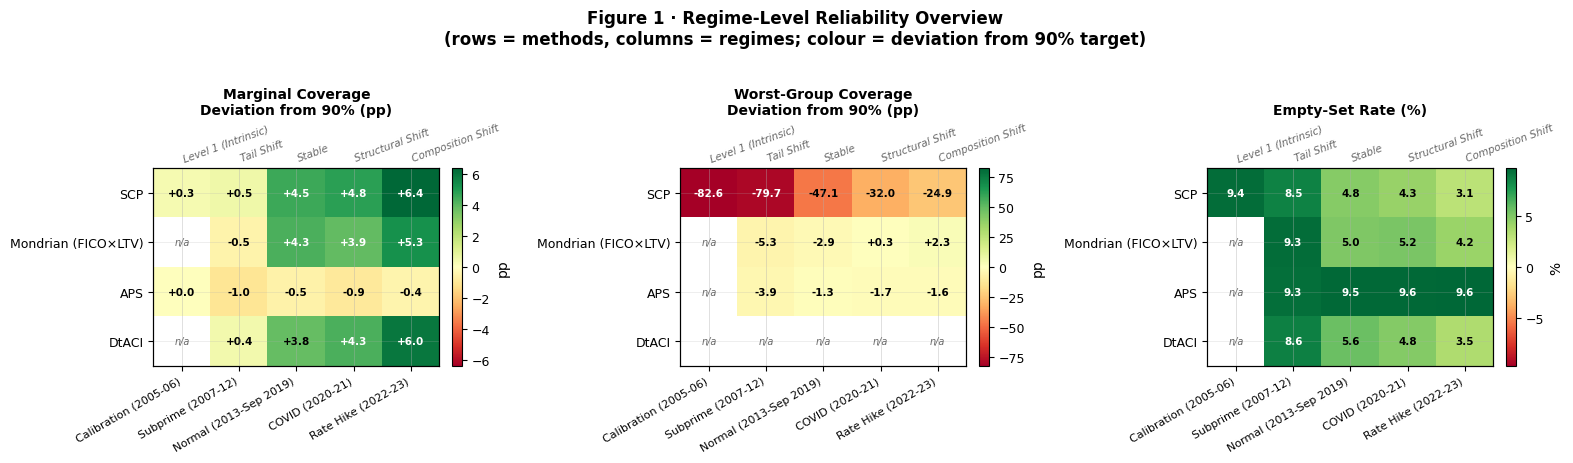

Figure 1 saved.


In [ ]:
# ── Figure 1: Regime-level reliability heatmap (deviation from 0.90) ─────────
#
# One panel per metric (marginal, worst-group, empty-set rate).
# Rows = primary methods; columns = calibration anchor + 4 test regimes.
# Mechanism labels appear as column sub-headers.
#
# Reference: coverage-deviation heat maps are a standard diagnostic in applied
# conformal evaluation studies (e.g., Angelopoulos & Bates, 2023).

HEAT_SPLITS  = ["calibration"] + TEST_SPLITS
HEAT_METHODS = PRIMARY_METHODS
HEAT_MECH    = {
    "calibration"   : "Level 1 (Intrinsic)",
    "test_subprime" : "Tail Shift",
    "test_normal"   : "Stable",
    "test_covid"    : "Structural Shift",
    "test_rate_hike": "Composition Shift",
}

def _get_val(df, split, method, col, default=np.nan):
    row = df[(df["split"] == split) & (df["method"] == method)]
    if row.empty or col not in row.columns:
        return default
    return row[col].iloc[0]

# Build matrices
mc_mat  = np.full((len(HEAT_METHODS), len(HEAT_SPLITS)), np.nan)
wgc_mat = np.full_like(mc_mat, np.nan)
er_mat  = np.full_like(mc_mat, np.nan)

for j, spl in enumerate(HEAT_SPLITS):
    for i, meth in enumerate(HEAT_METHODS):
        mc_mat[i, j]  = _get_val(metrics_df, spl, meth, "dev_from_nom_pp")
        wgc_mat[i, j] = _get_val(metrics_df, spl, meth, "wgc",  np.nan)
        er_mat[i, j]  = _get_val(metrics_df, spl, meth, "empty_rate_pct", np.nan)

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
fig.suptitle(
    "Figure 1 · Regime-Level Reliability Overview\n"
    "(rows = methods, columns = regimes; colour = deviation from 90% target)",
    fontsize=12, fontweight="bold", y=1.02
)

xlabels = [split_label(s) for s in HEAT_SPLITS]
ylabels = [METHOD_LABELS.get(m, m) for m in HEAT_METHODS]

for ax, mat, title, unit in zip(
    axes,
    [mc_mat,            wgc_mat * 100 - 90, er_mat],
    ["Marginal Coverage\nDeviation from 90% (pp)",
     "Worst-Group Coverage\nDeviation from 90% (pp)",
     "Empty-Set Rate (%)"],
    ["pp", "pp", "%"]
):
    vabs = max(abs(np.nanmin(mat)), abs(np.nanmax(mat)), 2)
    norm = TwoSlopeNorm(vmin=-vabs, vcenter=0, vmax=vabs)
    im   = ax.imshow(mat, cmap="RdYlGn", norm=norm, aspect="auto")
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label=unit)

    ax.set_xticks(range(len(HEAT_SPLITS)))
    ax.set_xticklabels(xlabels, rotation=30, ha="right", fontsize=8)
    ax.set_yticks(range(len(HEAT_METHODS)))
    ax.set_yticklabels(ylabels, fontsize=9)
    ax.set_title(title, fontsize=10, fontweight="bold")

    for i in range(len(HEAT_METHODS)):
        for j in range(len(HEAT_SPLITS)):
            v = mat[i, j]
            if not np.isnan(v):
                ax.text(
                    j, i,
                    f"{v:+.1f}" if unit == "pp" else f"{v:.1f}",
                    ha="center", va="center",
                    fontsize=7.5, fontweight="bold",
                    color="white" if abs(v) > vabs * 0.6 else "black"
                )
            else:
                ax.text(
                    j, i, "n/a",
                    ha="center", va="center",
                    fontsize=7, style="italic", color="dimgray"
                )

    ax2 = ax.twiny()
    ax2.set_xlim(ax.get_xlim())
    ax2.set_xticks(range(len(HEAT_SPLITS)))
    ax2.set_xticklabels(
        [HEAT_MECH[s] for s in HEAT_SPLITS],
        rotation=20, ha="left", fontsize=7.5,
        color="dimgray", style="italic"
    )
    ax2.tick_params(length=0)

fig.tight_layout()
fig.savefig(FIG_DIR / "fig1_regime_reliability_heatmap.png",
            bbox_inches="tight", dpi=FIG_DPI)
plt.show()
print("Figure 1 saved.")

# Underlying result data
fig1_source_df = pd.DataFrame([
    {
        "split": spl,
        "split_label": split_label(spl),
        "mechanism": HEAT_MECH[spl],
        "method": meth,
        "method_label": METHOD_LABELS.get(meth, meth),
        "marginal_cov_dev_pp": _get_val(metrics_df, spl, meth, "dev_from_nom_pp"),
        "worst_group_cov_pct": (
            _get_val(metrics_df, spl, meth, "wgc") * 100
            if pd.notna(_get_val(metrics_df, spl, meth, "wgc")) else np.nan
        ),
        "worst_group_cov_dev_pp": (
            _get_val(metrics_df, spl, meth, "wgc") * 100 - 90
            if pd.notna(_get_val(metrics_df, spl, meth, "wgc")) else np.nan
        ),
        "empty_rate_pct": _get_val(metrics_df, spl, meth, "empty_rate_pct"),
    }
    for spl in HEAT_SPLITS
    for meth in HEAT_METHODS
])

In [ ]:
# Figure 1 underlying result data
display_full_df(
    fig1_source_df,
    title="Figure 1 underlying result data",
    sort_by=["split", "method"],
    round_digits=4,
)


=== Figure 1 underlying result data ===


,split,split_label,mechanism,method,method_label,marginal_cov_dev_pp,worst_group_cov_pct,worst_group_cov_dev_pp,empty_rate_pct
0,calibration,Calibration (2005-06),Level 1 (Intrinsic),aps,APS,0.0000,NaN,NaN,NaN
1,calibration,Calibration (2005-06),Level 1 (Intrinsic),dtaci,DtACI,NaN,NaN,NaN,NaN
2,calibration,Calibration (2005-06),Level 1 (Intrinsic),mondrian_fico_ltv,Mondrian (FICO×LTV),NaN,NaN,NaN,NaN
3,calibration,Calibration (2005-06),Level 1 (Intrinsic),scp,SCP,0.3027,7.4184,-82.5816,9.4060
4,test_covid,COVID (2020-21),Structural Shift,aps,APS,-0.8577,88.2794,-1.7206,9.5550
5,test_covid,COVID (2020-21),Structural Shift,dtaci,DtACI,4.3033,NaN,NaN,4.8353
6,test_covid,COVID (2020-21),Structural Shift,mondrian_fico_ltv,Mondrian (FICO×LTV),3.9038,90.3491,0.3491,5.1791
7,test_covid,COVID (2020-21),Structural Shift,scp,SCP,4.8271,58.0326,-31.9674,4.2905
8,test_normal,Normal (2013-Sep 2019),Stable,aps,APS,-0.5388,88.7219,-1.2781,9.5167
9,test_normal,Normal (2013-Sep 2019),Stable,dtaci,DtACI,3.8071,NaN,NaN,5.5814


         split            split_label           mechanism            method        method_label  marginal_cov_dev_pp  worst_group_cov_pct  worst_group_cov_dev_pp  empty_rate_pct
   calibration  Calibration (2005-06) Level 1 (Intrinsic)               aps                 APS               0.0000                  NaN                     NaN             NaN
   calibration  Calibration (2005-06) Level 1 (Intrinsic)             dtaci               DtACI                  NaN                  NaN                     NaN             NaN
   calibration  Calibration (2005-06) Level 1 (Intrinsic) mondrian_fico_ltv Mondrian (FICO×LTV)                  NaN                  NaN                     NaN             NaN
   calibration  Calibration (2005-06) Level 1 (Intrinsic)               scp                 SCP               0.3027               7.4184                -82.5816          9.4060
    test_covid        COVID (2020-21)    Structural Shift               aps                 APS              -

In [ ]:
# ── Table 1: Compact regime-level summary ──────────────────
summary_rows = []
for spl in TEST_SPLITS:
    for meth in PRIMARY_METHODS:
        row = metrics_df[(metrics_df["split"] == spl) & (metrics_df["method"] == meth)]
        if row.empty:
            continue
        r = row.iloc[0]
        summary_rows.append({
            "Regime"      : split_label(spl),
            "Mechanism"   : HEAT_MECH[spl],
            "Method"      : METHOD_LABELS[meth],
            "MC (%)"      : f"{r['marginal_cov']*100:.2f}",
            "Dev (pp)"    : f"{r['dev_from_nom_pp']:+.2f}",
            "Cov(y=1) (%)": f"{r['cov_y1_pct']:.4f}",
            "Empty (%)"   : f"{r['empty_rate_pct']:.2f}",
            "CovGap (pp)" : f"{r['covgap_pp']:.2f}" if pd.notna(r.get('covgap_pp')) else "-",
            "WGC (%)"     : f"{r['wgc']*100:.2f}" if pd.notna(r.get('wgc')) else "-",
        })

summary_tbl = pd.DataFrame(summary_rows)
summary_tbl.to_csv(NB07_OUT_DIR / "nb07_regime_summary.csv", index=False)
print(summary_tbl.to_string(index=False))

                Regime         Mechanism              Method MC (%) Dev (pp) Cov(y=1) (%) Empty (%) CovGap (pp) WGC (%)
    Subprime (2007-12)        Tail Shift                 SCP  90.51    +0.51       0.0007      8.52       79.69   10.31
    Subprime (2007-12)        Tail Shift Mondrian (FICO×LTV)  89.50    -0.50       0.9752      9.34        5.26   84.74
    Subprime (2007-12)        Tail Shift                 APS  88.99    -1.01      29.5663      9.32        3.92   86.08
    Subprime (2007-12)        Tail Shift               DtACI  90.42    +0.42       0.0007      8.64           -       -
Normal (2013-Sep 2019)            Stable                 SCP  94.55    +4.55       0.0002      4.82       47.07   42.93
Normal (2013-Sep 2019)            Stable Mondrian (FICO×LTV)  94.27    +4.27       0.7945      5.01        7.34   87.11
Normal (2013-Sep 2019)            Stable                 APS  89.46    -0.54      29.0974      9.52        1.28   88.72
Normal (2013-Sep 2019)            Stable

---
## Section 5 · Class-Conditional Coverage Decomposition (Figure 2)

### Theoretical background

Marginal coverage can satisfy the 90% guarantee while simultaneously delivering near-zero coverage for the positive class. This is not a failure in the formal sense of SCP - it is the exact behaviour the marginal guarantee permits. At the calibration-split positive rate, the positive-class term contributes negligibly to marginal coverage regardless of $\text{Cov}(y=1)$.

### Calibration-anchor interpretation

Exact calibration-split Cov(y=0), Cov(y=1), and marginal-coverage values are read  
dynamically from `cp_manifest.json` and appear as the first column  
of Figure 2 below. The pattern consistently shows near-zero Cov(y=1) under SCP and  
a substantially higher but still incomplete Cov(y=1) under APS.  

This is the **Level 1 intrinsic failure**. It is present even before any temporal shift.  
APS (Romano, Sesia & Candès, 2020) uses the generalised inverse quantile (GIQ) conformity  
score, which ranks classes by predicted probability and accumulates cumulative probability  
mass up to the true label, rather than using only the true-class predicted probability.  
This produces empirically better class-conditional coverage in NB07 - an observed mitigation,  
not a formal class-conditional guarantee.

> **Key distinction:** Class-conditional collapse at the calibration level is a Level 1  
> (intrinsic) failure - it arises from the extreme class imbalance and threshold calibration  
> on a mixture dominated by the majority (non-delinquent) class (Löfström et al., 2015). It is distinct from temporal drift.


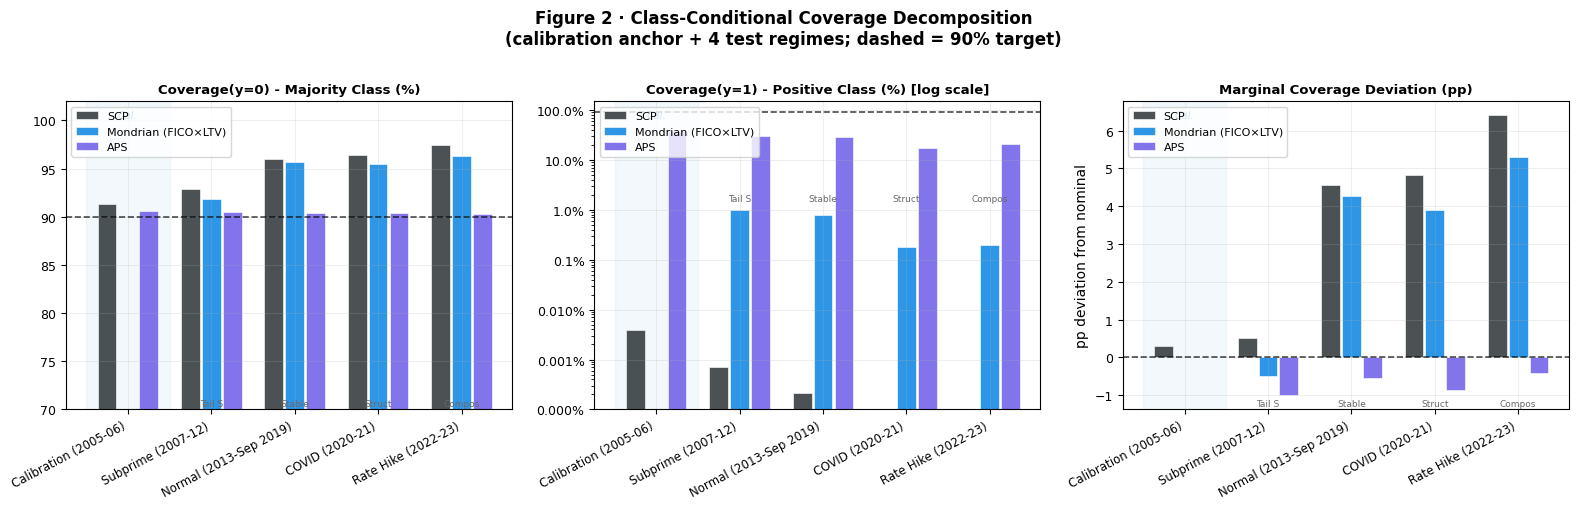

Figure 2 saved.


In [ ]:
# ── Figure 2: Class-conditional coverage - calibration anchor + test regimes ──
#
# Three panels:
#   (a) Coverage(y=0) - majority class
#   (b) Coverage(y=1) - positive class (log scale due to extreme values)
#   (c) Marginal coverage deviation (pp)
#
# Methods shown: SCP, Mondrian(FICO×LTV), APS.
# DtACI is omitted only to keep Figure 2 focused on the three static methods;
# its regime-level class-conditional coverage is reported in the method summary.
#
# Reference: class-conditional coverage decomposition follows the Mondrian CP framework
# (Vovk, 2012). Ding et al., 2023 address the same
# phenomenon but target the many-class setting (≥100 classes); the binary case here
# is directly driven by class imbalance, not label multiplicity. General framing of
# class-conditional diagnostics follows Angelopoulos & Bates (2023).

CC_METHODS  = ["scp", "mondrian_fico_ltv", "aps"]
CC_SPLITS   = ["calibration"] + TEST_SPLITS
CC_LABELS   = [split_label(s) for s in CC_SPLITS]
CC_COLORS   = [METHOD_COLORS.get(m, "#999") for m in CC_METHODS]

cc_data = {meth: {"cov_y0": [], "cov_y1": [], "mc": []} for meth in CC_METHODS}
for spl in CC_SPLITS:
    for meth in CC_METHODS:
        row = metrics_df[(metrics_df["split"] == spl) & (metrics_df["method"] == meth)]
        if row.empty:
            for k in ["cov_y0", "cov_y1", "mc"]:
                cc_data[meth][k].append(np.nan)
        else:
            r = row.iloc[0]
            cc_data[meth]["cov_y0"].append(float(r.get("cov_y0", np.nan)) * 100)
            cc_data[meth]["cov_y1"].append(float(r.get("cov_y1", np.nan)) * 100)
            cc_data[meth]["mc"].append(float(r.get("dev_from_nom_pp", np.nan)))

x = np.arange(len(CC_SPLITS))
w = 0.25

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle(
    "Figure 2 · Class-Conditional Coverage Decomposition\n"
    "(calibration anchor + 4 test regimes; dashed = 90% target)",
    fontsize=12, fontweight="bold", y=1.01
)

titles = [
    "Coverage(y=0) - Majority Class (%)",
    "Coverage(y=1) - Positive Class (%) [log scale]",
    "Marginal Coverage Deviation (pp)"
]
data_keys = ["cov_y0", "cov_y1", "mc"]

for ax, key, title in zip(axes, data_keys, titles):
    for k, meth in enumerate(CC_METHODS):
        vals = cc_data[meth][key]
        ax.bar(
            x + (k - 1) * w, vals, w * 0.9,
            color=CC_COLORS[k], label=METHOD_LABELS[meth], alpha=0.85,
            edgecolor="white", linewidth=0.5
        )
    ax.set_title(title, fontsize=9.5, fontweight="bold")
    ax.set_xticks(x)
    ax.set_xticklabels(CC_LABELS, rotation=28, ha="right", fontsize=8.5)
    ax.legend(fontsize=8, loc="upper left")
    ax.grid(axis="y", alpha=0.3)
    if key == "cov_y0":
        ax.axhline(90, color="black", ls="--", lw=1.2, alpha=0.7, label="90% target")
        ax.set_ylim(70, 102)
    elif key == "cov_y1":
        ax.set_yscale("log")
        ax.yaxis.set_major_formatter(
            mticker.FuncFormatter(lambda y, _: f"{y:.3f}%" if y < 0.1 else f"{y:.1f}%")
        )
        ax.set_ylim(1e-4, 150)
        ax.axhline(90, color="black", ls="--", lw=1.2, alpha=0.7)
    else:
        ax.axhline(0, color="black", ls="--", lw=1.2, alpha=0.7)
        ax.set_ylabel("pp deviation from nominal")

    ax.axvspan(-0.5, 0.5, color="#d6eaf8", alpha=0.3, zorder=0)
    # Use a fixed position in axes-fraction coordinates to avoid log-scale distortion.
    ax.text(
        0, 0.97, "Cal.",
        transform=ax.get_xaxis_transform(),
        ha="center", fontsize=7.5, color="#2980b9", style="italic", va="top"
    )

    for j, spl in enumerate(CC_SPLITS[1:], start=1):
        ax.text(
            j,
            ax.get_ylim()[0] + (ax.get_ylim()[1] - ax.get_ylim()[0]) * 0.01,
            HEAT_MECH.get(spl, "")[:6],
            ha="center", fontsize=6.5, color="dimgray"
        )

fig.tight_layout()
fig.savefig(FIG_DIR / "fig2_class_conditional_coverage.png",
            bbox_inches="tight", dpi=FIG_DPI)
plt.show()
print("Figure 2 saved.")

In [ ]:
# Figure 2 underlying result data
print("\n=== Key class-conditional numbers ===")
for spl in ["calibration", "test_subprime", "test_rate_hike"]:
    for meth in ["scp", "aps"]:
        row = metrics_df[(metrics_df["split"] == spl) & (metrics_df["method"] == meth)]
        if not row.empty:
            r = row.iloc[0]
            print(
                f"  {SPLIT_LABELS.get(spl, spl)[:12]:<12}  {METHOD_LABELS[meth]:<20}  "
                f"Cov(y=1) = {r.get('cov_y1', np.nan) * 100:.6f}%"
            )

# Underlying result data
fig2_source_df = pd.DataFrame([
    {
        "split": spl,
        "split_label": split_label(spl),
        "method": meth,
        "method_label": METHOD_LABELS.get(meth, meth),
        "cov_y0_pct": cc_data[meth]["cov_y0"][idx],
        "cov_y1_pct": cc_data[meth]["cov_y1"][idx],
        "marginal_cov_dev_pp": cc_data[meth]["mc"][idx],
    }
    for idx, spl in enumerate(CC_SPLITS)
    for meth in CC_METHODS
])

display_full_df(
    fig2_source_df,
    title="Figure 2 underlying result data",
    sort_by=["split", "method"],
    round_digits=6,
)


=== Key class-conditional numbers ===
  Calibration
  SCP                   Cov(y=1) = 0.003860%
  Calibration
  APS                   Cov(y=1) = 37.604594%
  Subprime
(20  SCP                   Cov(y=1) = 0.000700%
  Subprime
(20  APS                   Cov(y=1) = 29.566347%
  Rate Hike
(2  SCP                   Cov(y=1) = 0.000063%
  Rate Hike
(2  APS                   Cov(y=1) = 21.217946%

=== Figure 2 underlying result data ===


,split,split_label,method,method_label,cov_y0_pct,cov_y1_pct,marginal_cov_dev_pp
0,calibration,Calibration (2005-06),aps,APS,90.586739,37.604594,0.000001
1,calibration,Calibration (2005-06),mondrian_fico_ltv,Mondrian (FICO×LTV),NaN,NaN,NaN
2,calibration,Calibration (2005-06),scp,SCP,91.313849,0.003860,0.302657
3,test_covid,COVID (2020-21),aps,APS,90.371805,17.153035,-0.857732
4,test_covid,COVID (2020-21),mondrian_fico_ltv,Mondrian (FICO×LTV),95.504529,0.183426,3.903835
5,test_covid,COVID (2020-21),scp,SCP,96.446708,0.000000,4.827112
6,test_normal,Normal (2013-Sep 2019),aps,APS,90.391238,29.097389,-0.538790
7,test_normal,Normal (2013-Sep 2019),mondrian_fico_ltv,Mondrian (FICO×LTV),95.708814,0.794537,4.268654
8,test_normal,Normal (2013-Sep 2019),scp,SCP,96.004931,0.000210,4.548225
9,test_rate_hike,Rate Hike (2022-23),aps,APS,90.304719,21.217946,-0.415615


         split            split_label            method        method_label  cov_y0_pct  cov_y1_pct  marginal_cov_dev_pp
   calibration  Calibration (2005-06)               aps                 APS   90.586739   37.604594             0.000001
   calibration  Calibration (2005-06) mondrian_fico_ltv Mondrian (FICO×LTV)         NaN         NaN                  NaN
   calibration  Calibration (2005-06)               scp                 SCP   91.313849    0.003860             0.302657
    test_covid        COVID (2020-21)               aps                 APS   90.371805   17.153035            -0.857732
    test_covid        COVID (2020-21) mondrian_fico_ltv Mondrian (FICO×LTV)   95.504529    0.183426             3.903835
    test_covid        COVID (2020-21)               scp                 SCP   96.446708    0.000000             4.827112
   test_normal Normal (2013-Sep 2019)               aps                 APS   90.391238   29.097389            -0.538790
   test_normal Normal (2013-Sep 

---
## Section 6 · Subgroup-Conditional Reliability: FICO × LTV (Figures 3a-3b)

### Why FICO × LTV is the primary partition

Under exchangeability of calibration and test observations within each predefined group, Mondrian CP provides group-conditional validity on that partition (Vovk, 2012). Here, the deployment windows are non-exchangeable by design, so the realised subgroup results are empirical reliability diagnostics.

NB05b's FICO × LTV thresholds vary by 128.7× across observed non-sentinel cells, consistent with strong subgroup score heterogeneity under a single global SCP threshold.

The FICO × LTV partition is economically motivated:  
- FICO score proxies for borrower creditworthiness and repayment risk (Siddiqi, 2017)
- LTV ratio proxies for collateral adequacy and strategic default incentive  
(see Deng, Quigley & Van Order, 2000; Campbell & Cocco, 2015 for the equity theory of mortgage default)

### Reading the heatmaps

The heatmaps omit Sentinel, despite the legacy figure subtitle; CovGap/WGC
still use all FICO $\times$ LTV cells with $n \ge 30$, including Sentinel. Red
denotes coverage below 90%; green above 90%.


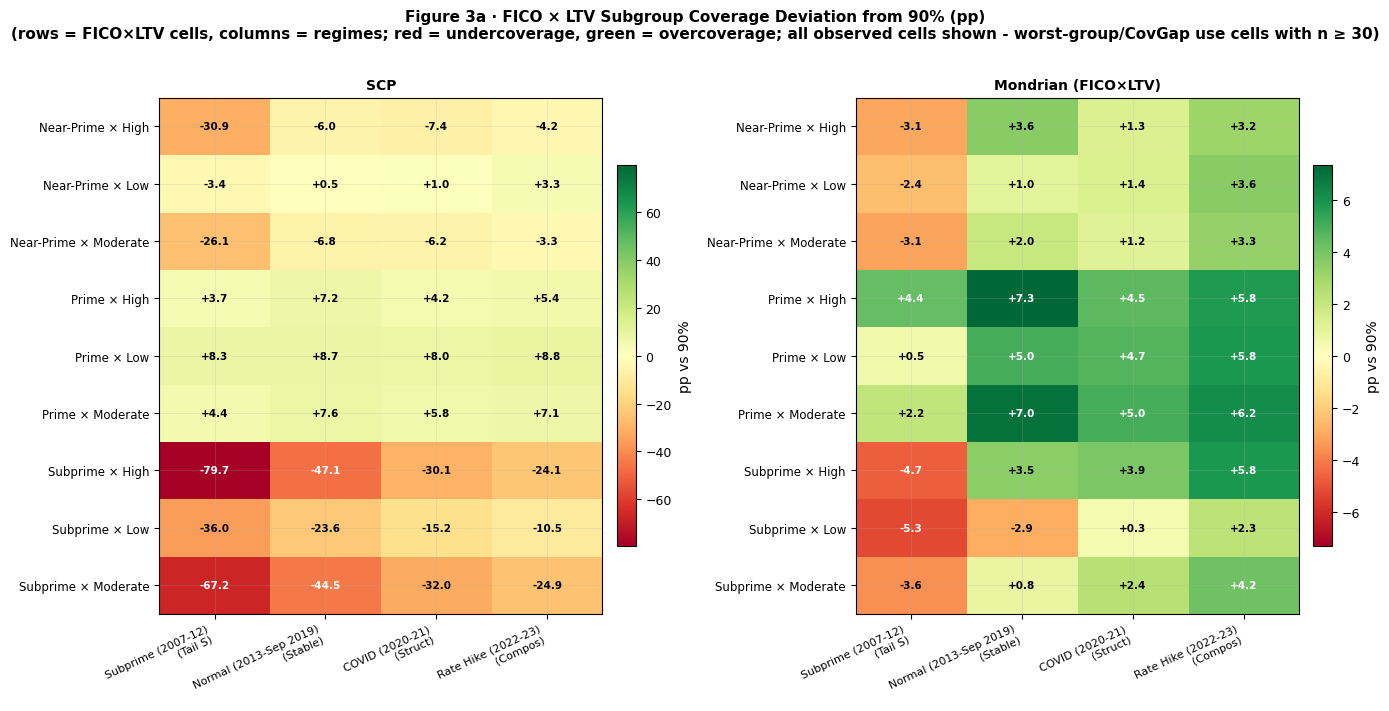

Figure 3a saved.


In [ ]:
# ── Figure 3a: FICO × LTV coverage heatmaps - SCP vs Mondrian (FICO×LTV) ────
#
# For each method, show coverage(pp deviation from 90%) for each FICO×LTV cell
# across 4 test regimes. Rows = cells, columns = regimes.
#
# Reference: the CovGap metric concept follows Ding et al. (2023) §3.2 (defined
# there as mean absolute deviation of class-conditional coverage from target, averaged
# across classes; the thesis uses a max-absolute-deviation variant across FICO×LTV groups).

SG_DIM = "fico_ltv_group"

def get_subgroup_matrix(method, dimension=SG_DIM):
    """
    Returns (cells, regimes, matrix) where matrix[i,j] = coverage deviation (pp)
    for cell i in split j. Uses only TEST_SPLITS (no calibration split in subgroup data).
    """
    all_cells = set()
    for spl in TEST_SPLITS:
        sg_meth = COV_METRICS["subgroup"].get(spl, {}).get(method, {})
        cells_here = sg_meth.get(dimension, {}).keys()
        all_cells.update(cells_here)
    cells = sorted(c for c in all_cells if c != "Sentinel")

    mat = np.full((len(cells), len(TEST_SPLITS)), np.nan)
    for j, spl in enumerate(TEST_SPLITS):
        for i, cell in enumerate(cells):
            val = (
                COV_METRICS["subgroup"]
                .get(spl, {})
                .get(method, {})
                .get(dimension, {})
                .get(cell, {})
                .get("marginal_cov", np.nan)
            )
            mat[i, j] = (
                (float(val) - NOMINAL_COV) * 100
                if not isinstance(val, float) or not np.isnan(float(val))
                else np.nan
            )
    return cells, TEST_SPLITS, mat

HM_METHODS = ["scp", "mondrian_fico_ltv"]
fig, axes = plt.subplots(1, 2, figsize=(14, 7))
fig.suptitle(
    "Figure 3a · FICO × LTV Subgroup Coverage Deviation from 90% (pp)\n"
    "(rows = FICO×LTV cells, columns = regimes; red = undercoverage, green = overcoverage; "
    "all observed cells shown - worst-group/CovGap use cells with n ≥ 30)",
    fontsize=11, fontweight="bold", y=1.01
)

for ax, meth in zip(axes, HM_METHODS):
    cells, splits, mat = get_subgroup_matrix(meth)
    vabs = max(abs(np.nanmin(mat)), abs(np.nanmax(mat)), 5)
    norm = TwoSlopeNorm(vmin=-vabs, vcenter=0, vmax=vabs)
    im = ax.imshow(mat, cmap="RdYlGn", norm=norm, aspect="auto")
    plt.colorbar(im, ax=ax, fraction=0.04, pad=0.03, label="pp vs 90%")

    ax.set_yticks(range(len(cells)))
    ax.set_yticklabels(cells, fontsize=8.5)
    ax.set_xticks(range(len(splits)))
    ax.set_xticklabels(
        [split_label(s) + f"\n({HEAT_MECH[s][:6]})" for s in splits],
        rotation=25, ha="right", fontsize=8
    )
    ax.set_title(f"{METHOD_LABELS[meth]}", fontsize=10, fontweight="bold")

    for i in range(len(cells)):
        for j in range(len(splits)):
            v = mat[i, j]
            if not np.isnan(v):
                ax.text(
                    j, i, f"{v:+.1f}",
                    ha="center", va="center",
                    fontsize=7.5, fontweight="bold",
                    color="white" if abs(v) > vabs * 0.55 else "black"
                )

fig.tight_layout()
fig.savefig(FIG_DIR / "fig3a_fico_ltv_heatmap_scp_mondrian.png",
            bbox_inches="tight", dpi=FIG_DPI)
plt.show()
print("Figure 3a saved.")

# Underlying result data
fig3a_rows = []
for meth in HM_METHODS:
    cells, splits, mat = get_subgroup_matrix(meth)
    for i, cell in enumerate(cells):
        for j, spl in enumerate(splits):
            fig3a_rows.append({
                "method": meth,
                "method_label": METHOD_LABELS.get(meth, meth),
                "split": spl,
                "split_label": split_label(spl),
                "subgroup_dimension": SG_DIM,
                "subgroup_cell": cell,
                "coverage_dev_pp": mat[i, j],
            })

fig3a_source_df = pd.DataFrame(fig3a_rows)

In [ ]:
# Figure 3a underlying result data
display_full_df(
    fig3a_source_df,
    title="Figure 3a underlying result data",
    sort_by=["method", "subgroup_cell", "split"],
    round_digits=4,
)


=== Figure 3a underlying result data ===


,method,method_label,split,split_label,subgroup_dimension,subgroup_cell,coverage_dev_pp
0,mondrian_fico_ltv,Mondrian (FICO×LTV),test_covid,COVID (2020-21),fico_ltv_group,Near-Prime × High,1.3084
1,mondrian_fico_ltv,Mondrian (FICO×LTV),test_normal,Normal (2013-Sep 2019),fico_ltv_group,Near-Prime × High,3.5864
2,mondrian_fico_ltv,Mondrian (FICO×LTV),test_rate_hike,Rate Hike (2022-23),fico_ltv_group,Near-Prime × High,3.1508
3,mondrian_fico_ltv,Mondrian (FICO×LTV),test_subprime,Subprime (2007-12),fico_ltv_group,Near-Prime × High,-3.0936
4,mondrian_fico_ltv,Mondrian (FICO×LTV),test_covid,COVID (2020-21),fico_ltv_group,Near-Prime × Low,1.3532
5,mondrian_fico_ltv,Mondrian (FICO×LTV),test_normal,Normal (2013-Sep 2019),fico_ltv_group,Near-Prime × Low,1.0103
6,mondrian_fico_ltv,Mondrian (FICO×LTV),test_rate_hike,Rate Hike (2022-23),fico_ltv_group,Near-Prime × Low,3.6100
7,mondrian_fico_ltv,Mondrian (FICO×LTV),test_subprime,Subprime (2007-12),fico_ltv_group,Near-Prime × Low,-2.4229
8,mondrian_fico_ltv,Mondrian (FICO×LTV),test_covid,COVID (2020-21),fico_ltv_group,Near-Prime × Moderate,1.1545
9,mondrian_fico_ltv,Mondrian (FICO×LTV),test_normal,Normal (2013-Sep 2019),fico_ltv_group,Near-Prime × Moderate,1.9548


           method        method_label          split            split_label subgroup_dimension         subgroup_cell  coverage_dev_pp
mondrian_fico_ltv Mondrian (FICO×LTV)     test_covid        COVID (2020-21)     fico_ltv_group     Near-Prime × High           1.3084
mondrian_fico_ltv Mondrian (FICO×LTV)    test_normal Normal (2013-Sep 2019)     fico_ltv_group     Near-Prime × High           3.5864
mondrian_fico_ltv Mondrian (FICO×LTV) test_rate_hike    Rate Hike (2022-23)     fico_ltv_group     Near-Prime × High           3.1508
mondrian_fico_ltv Mondrian (FICO×LTV)  test_subprime     Subprime (2007-12)     fico_ltv_group     Near-Prime × High          -3.0936
mondrian_fico_ltv Mondrian (FICO×LTV)     test_covid        COVID (2020-21)     fico_ltv_group      Near-Prime × Low           1.3532
mondrian_fico_ltv Mondrian (FICO×LTV)    test_normal Normal (2013-Sep 2019)     fico_ltv_group      Near-Prime × Low           1.0103
mondrian_fico_ltv Mondrian (FICO×LTV) test_rate_hike    Rate H

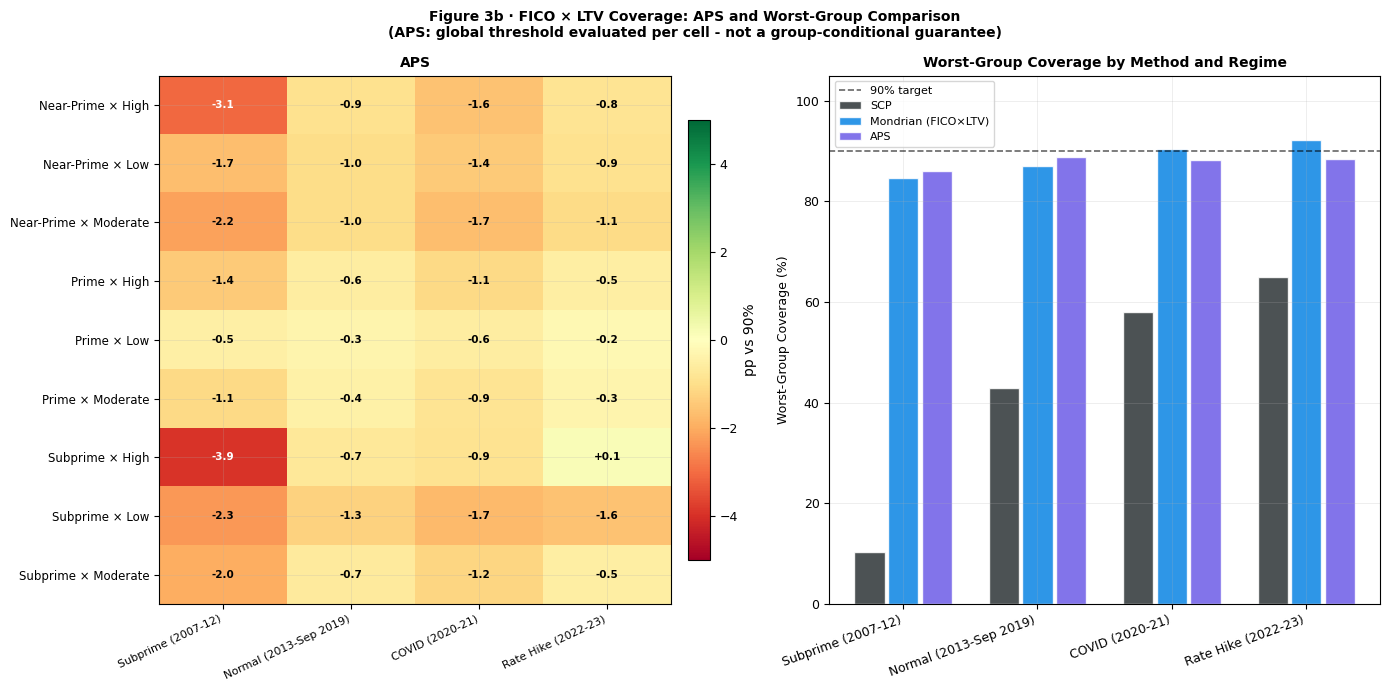


Figure 3b saved.


In [ ]:
# ── Figure 3b: APS subgroup heatmap + worst-group summary ────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 7))
fig.suptitle(
    "Figure 3b · FICO × LTV Coverage: APS and Worst-Group Comparison\n"
    "(APS: global threshold evaluated per cell - not a group-conditional guarantee)",
    fontsize=10, fontweight="bold"
)

# Left: APS heatmap
cells_aps, splits_aps, mat_aps = get_subgroup_matrix("aps")
vabs = max(abs(np.nanmin(mat_aps)), abs(np.nanmax(mat_aps)), 5)
norm = TwoSlopeNorm(vmin=-vabs, vcenter=0, vmax=vabs)
im = axes[0].imshow(mat_aps, cmap="RdYlGn", norm=norm, aspect="auto")
plt.colorbar(im, ax=axes[0], fraction=0.04, pad=0.03, label="pp vs 90%")
axes[0].set_yticks(range(len(cells_aps)))
axes[0].set_yticklabels(cells_aps, fontsize=8.5)
axes[0].set_xticks(range(len(splits_aps)))
axes[0].set_xticklabels(
    [split_label(s) for s in splits_aps],
    rotation=25, ha="right", fontsize=8
)
axes[0].set_title("APS", fontsize=10, fontweight="bold")
for i in range(len(cells_aps)):
    for j in range(len(splits_aps)):
        v = mat_aps[i, j]
        if not np.isnan(v):
            axes[0].text(
                j, i, f"{v:+.1f}", ha="center", va="center",
                fontsize=7.5, fontweight="bold",
                color="white" if abs(v) > vabs * 0.55 else "black"
            )

# Right: Worst-group coverage comparison bar chart
ax2 = axes[1]
wgc_methods = [m for m in ["scp", "mondrian_fico_ltv", "aps"] if m in covgap_df["method"].values]
x = np.arange(len(TEST_SPLITS))
w = 0.25
for k, meth in enumerate(wgc_methods):
    wgc_vals = []
    cg_vals  = []
    for spl in TEST_SPLITS:
        row = covgap_df[(covgap_df["split"] == spl) & (covgap_df["method"] == meth)]
        wgc_vals.append(row["wgc"].iloc[0] * 100 if not row.empty else np.nan)
        cg_vals.append(row["covgap_pp"].iloc[0] if not row.empty else np.nan)
    ax2.bar(
        x + (k - 1) * w, wgc_vals, w * 0.9,
        color=METHOD_COLORS.get(meth, "#999"),
        label=METHOD_LABELS[meth], alpha=0.85, edgecolor="white"
    )

ax2.axhline(90, color="black", ls="--", lw=1.2, alpha=0.6, label="90% target")
ax2.set_xticks(x)
ax2.set_xticklabels([split_label(s) for s in TEST_SPLITS],
                    rotation=20, ha="right", fontsize=9)
ax2.set_ylabel("Worst-Group Coverage (%)", fontsize=9)
ax2.set_title("Worst-Group Coverage by Method and Regime", fontsize=10, fontweight="bold")
ax2.legend(fontsize=8)
ax2.set_ylim(0, 105)
ax2.grid(axis="y", alpha=0.3)

fig.tight_layout()
fig.savefig(FIG_DIR / "fig3b_aps_heatmap_wgc.png",
            bbox_inches="tight", dpi=FIG_DPI)
plt.show()
print("\nFigure 3b saved.")

In [ ]:
# Figure 3b underlying result data
print("\n=== CovGap and Worst-Group Coverage by method and regime ===")
pivot_cg = covgap_df.pivot_table(
    index="method", columns="split", values="covgap_pp", aggfunc="first"
)[TEST_SPLITS]
pivot_cg.index = [METHOD_LABELS.get(m, m) for m in pivot_cg.index]

display_full_df(
    pivot_cg.reset_index().rename(columns={"index": "method_label"}),
    title="CovGap by method and regime",
    round_digits=2,
)

# Underlying result data
fig3b_aps_df = pd.DataFrame([
    {
        "method": "aps",
        "method_label": METHOD_LABELS.get("aps", "aps"),
        "split": spl,
        "split_label": split_label(spl),
        "subgroup_dimension": SG_DIM,
        "subgroup_cell": cell,
        "coverage_dev_pp": mat_aps[i, j],
    }
    for i, cell in enumerate(cells_aps)
    for j, spl in enumerate(splits_aps)
])

fig3b_wgc_df = pd.DataFrame([
    {
        "split": spl,
        "split_label": split_label(spl),
        "method": meth,
        "method_label": METHOD_LABELS.get(meth, meth),
        "worst_group_coverage_pct": (
            covgap_df[(covgap_df["split"] == spl) & (covgap_df["method"] == meth)]["wgc"].iloc[0] * 100
            if not covgap_df[(covgap_df["split"] == spl) & (covgap_df["method"] == meth)].empty else np.nan
        ),
        "covgap_pp": (
            covgap_df[(covgap_df["split"] == spl) & (covgap_df["method"] == meth)]["covgap_pp"].iloc[0]
            if not covgap_df[(covgap_df["split"] == spl) & (covgap_df["method"] == meth)].empty else np.nan
        ),
    }
    for spl in TEST_SPLITS
    for meth in wgc_methods
])

display_full_df(
    fig3b_aps_df,
    title="Figure 3b underlying APS heatmap data",
    sort_by=["subgroup_cell", "split"],
    round_digits=4,
)

display_full_df(
    fig3b_wgc_df,
    title="Figure 3b underlying worst-group summary data",
    sort_by=["split", "method"],
    round_digits=4,
)


=== CovGap and Worst-Group Coverage by method and regime ===

=== CovGap by method and regime ===


split,method_label,test_subprime,test_normal,test_covid,test_rate_hike
0,APS,3.92,1.28,1.72,1.57
1,Mondrian (Census),76.28,51.46,33.95,27.04
2,Mondrian (FICO),42.38,14.44,20.86,20.37
3,Mondrian (FICO×LTV),5.26,7.34,5.04,6.15
4,Mondrian (LTV),49.83,35.18,25.08,19.24
5,SCP,79.69,47.07,31.97,24.94


       method_label  test_subprime  test_normal  test_covid  test_rate_hike
                APS           3.92         1.28        1.72            1.57
  Mondrian (Census)          76.28        51.46       33.95           27.04
    Mondrian (FICO)          42.38        14.44       20.86           20.37
Mondrian (FICO×LTV)           5.26         7.34        5.04            6.15
     Mondrian (LTV)          49.83        35.18       25.08           19.24
                SCP          79.69        47.07       31.97           24.94

=== Figure 3b underlying APS heatmap data ===


,method,method_label,split,split_label,subgroup_dimension,subgroup_cell,coverage_dev_pp
0,aps,APS,test_covid,COVID (2020-21),fico_ltv_group,Near-Prime × High,-1.5821
1,aps,APS,test_normal,Normal (2013-Sep 2019),fico_ltv_group,Near-Prime × High,-0.9359
2,aps,APS,test_rate_hike,Rate Hike (2022-23),fico_ltv_group,Near-Prime × High,-0.8258
3,aps,APS,test_subprime,Subprime (2007-12),fico_ltv_group,Near-Prime × High,-3.0853
4,aps,APS,test_covid,COVID (2020-21),fico_ltv_group,Near-Prime × Low,-1.4332
5,aps,APS,test_normal,Normal (2013-Sep 2019),fico_ltv_group,Near-Prime × Low,-1.0188
6,aps,APS,test_rate_hike,Rate Hike (2022-23),fico_ltv_group,Near-Prime × Low,-0.9021
7,aps,APS,test_subprime,Subprime (2007-12),fico_ltv_group,Near-Prime × Low,-1.6684
8,aps,APS,test_covid,COVID (2020-21),fico_ltv_group,Near-Prime × Moderate,-1.6661
9,aps,APS,test_normal,Normal (2013-Sep 2019),fico_ltv_group,Near-Prime × Moderate,-1.0317


method method_label          split            split_label subgroup_dimension         subgroup_cell  coverage_dev_pp
   aps          APS     test_covid        COVID (2020-21)     fico_ltv_group     Near-Prime × High          -1.5821
   aps          APS    test_normal Normal (2013-Sep 2019)     fico_ltv_group     Near-Prime × High          -0.9359
   aps          APS test_rate_hike    Rate Hike (2022-23)     fico_ltv_group     Near-Prime × High          -0.8258
   aps          APS  test_subprime     Subprime (2007-12)     fico_ltv_group     Near-Prime × High          -3.0853
   aps          APS     test_covid        COVID (2020-21)     fico_ltv_group      Near-Prime × Low          -1.4332
   aps          APS    test_normal Normal (2013-Sep 2019)     fico_ltv_group      Near-Prime × Low          -1.0188
   aps          APS test_rate_hike    Rate Hike (2022-23)     fico_ltv_group      Near-Prime × Low          -0.9021
   aps          APS  test_subprime     Subprime (2007-12)     fico_ltv_g

,split,split_label,method,method_label,worst_group_coverage_pct,covgap_pp
0,test_covid,COVID (2020-21),aps,APS,88.2794,1.7206
1,test_covid,COVID (2020-21),mondrian_fico_ltv,Mondrian (FICO×LTV),90.3491,5.0430
2,test_covid,COVID (2020-21),scp,SCP,58.0326,31.9674
3,test_normal,Normal (2013-Sep 2019),aps,APS,88.7219,1.2781
4,test_normal,Normal (2013-Sep 2019),mondrian_fico_ltv,Mondrian (FICO×LTV),87.1075,7.3370
5,test_normal,Normal (2013-Sep 2019),scp,SCP,42.9277,47.0723
6,test_rate_hike,Rate Hike (2022-23),aps,APS,88.4318,1.5682
7,test_rate_hike,Rate Hike (2022-23),mondrian_fico_ltv,Mondrian (FICO×LTV),92.2892,6.1518
8,test_rate_hike,Rate Hike (2022-23),scp,SCP,65.0622,24.9378
9,test_subprime,Subprime (2007-12),aps,APS,86.0783,3.9217


         split            split_label            method        method_label  worst_group_coverage_pct  covgap_pp
    test_covid        COVID (2020-21)               aps                 APS                   88.2794     1.7206
    test_covid        COVID (2020-21) mondrian_fico_ltv Mondrian (FICO×LTV)                   90.3491     5.0430
    test_covid        COVID (2020-21)               scp                 SCP                   58.0326    31.9674
   test_normal Normal (2013-Sep 2019)               aps                 APS                   88.7219     1.2781
   test_normal Normal (2013-Sep 2019) mondrian_fico_ltv Mondrian (FICO×LTV)                   87.1075     7.3370
   test_normal Normal (2013-Sep 2019)               scp                 SCP                   42.9277    47.0723
test_rate_hike    Rate Hike (2022-23)               aps                 APS                   88.4318     1.5682
test_rate_hike    Rate Hike (2022-23) mondrian_fico_ltv Mondrian (FICO×LTV)                   92

---
## Section 7 · Secondary Subgroup Views (FICO, LTV, Census)

These views supplement the FICO×LTV primary partition. They show whether the one-dimensional FICO/LTV groupings reproduce the interaction pattern and whether Census divisions reveal additional descriptive coverage heterogeneity.


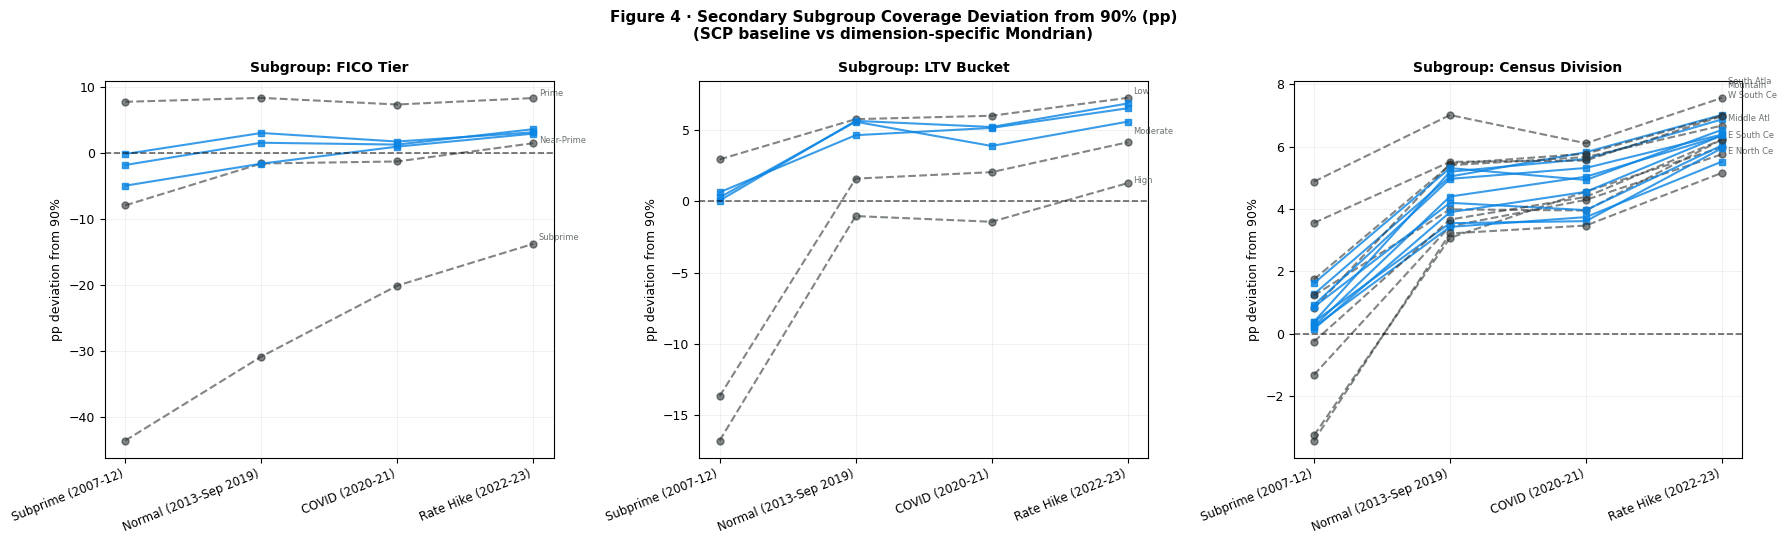

Figure 4 saved.


In [ ]:
# ── Figure 4: Secondary subgroup coverage deviation - FICO, LTV, Census ──────
fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))
fig.suptitle(
    "Figure 4 · Secondary Subgroup Coverage Deviation from 90% (pp)\n"
    "(SCP baseline vs dimension-specific Mondrian)",
    fontsize=11, fontweight="bold"
)

dim_specs = [
    ("fico_tier",       "mondrian_fico",   "FICO Tier"),
    ("ltv_bucket",      "mondrian_ltv",    "LTV Bucket"),
    ("census_division", "mondrian_census", "Census Division"),
]

fig4_rows = []

for ax, (dim, meth, label) in zip(axes, dim_specs):
    all_cells = set()
    for spl in TEST_SPLITS:
        c = COV_METRICS["subgroup"].get(spl, {}).get("scp", {}).get(dim, {}).keys()
        all_cells.update(c)
    dim_cells = sorted(c for c in all_cells if c != "Sentinel")

    mat_scp  = np.full((len(dim_cells), len(TEST_SPLITS)), np.nan)
    mat_mond = np.full_like(mat_scp, np.nan)

    for j, spl in enumerate(TEST_SPLITS):
        for i, cell in enumerate(dim_cells):
            for mat, m_key in [(mat_scp, "scp"), (mat_mond, meth)]:
                val = (
                    COV_METRICS["subgroup"]
                    .get(spl, {}).get(m_key, {}).get(dim, {})
                    .get(cell, {}).get("marginal_cov", np.nan)
                )
                mat[i, j] = (
                    (float(val) - NOMINAL_COV) * 100
                    if not (isinstance(val, float) and np.isnan(val))
                    else np.nan
                )

                fig4_rows.append({
                    "dimension": dim,
                    "dimension_label": label,
                    "method": m_key,
                    "method_label": METHOD_LABELS.get(m_key, m_key),
                    "split": spl,
                    "split_label": split_label(spl),
                    "subgroup_cell": cell,
                    "coverage_dev_pp": mat[i, j],
                })

    x_pos = np.arange(len(TEST_SPLITS))
    colors = [METHOD_COLORS["scp"], METHOD_COLORS.get(meth, "#0984e3")]

    for i, cell in enumerate(dim_cells):
        scp_v  = mat_scp[i, :]
        mond_v = mat_mond[i, :]
        ax.plot(
            x_pos, scp_v, "o--", color=colors[0], alpha=0.6, ms=5,
            label="SCP" if i == 0 else ""
        )
        ax.plot(
            x_pos, mond_v, "s-", color=colors[1], alpha=0.8, ms=5,
            label=f"Mondrian ({label})" if i == 0 else ""
        )
        ax.annotate(
            cell[:10], (x_pos[-1], scp_v[-1] + i * 0.3),
            fontsize=6, color=colors[0], alpha=0.7,
            xytext=(4, 0), textcoords="offset points"
        )

    ax.axhline(0, color="black", ls="--", lw=1.2, alpha=0.6)
    ax.set_xticks(x_pos)
    ax.set_xticklabels([split_label(s) for s in TEST_SPLITS],
                       rotation=22, ha="right", fontsize=8.5)
    ax.set_ylabel("pp deviation from 90%", fontsize=9)
    ax.set_title(f"Subgroup: {label}", fontsize=10, fontweight="bold")
    if i == 0:
        ax.legend(fontsize=8)
    ax.grid(alpha=0.25)

fig.tight_layout()
fig.savefig(FIG_DIR / "fig4_secondary_subgroup_views.png",
            bbox_inches="tight", dpi=FIG_DPI)
plt.show()
print("Figure 4 saved.")

# Underlying result data
fig4_source_df = pd.DataFrame(fig4_rows)

In [ ]:
# Figure 4 underlying result data
display_full_df(
    fig4_source_df,
    title="Figure 4 underlying result data",
    sort_by=["dimension", "method", "subgroup_cell", "split"],
    round_digits=4,
)


=== Figure 4 underlying result data ===


,dimension,dimension_label,method,method_label,split,split_label,subgroup_cell,coverage_dev_pp
0,census_division,Census Division,mondrian_census,Mondrian (Census),test_covid,COVID (2020-21),E North Central,5.0354
1,census_division,Census Division,mondrian_census,Mondrian (Census),test_normal,Normal (2013-Sep 2019),E North Central,4.3981
2,census_division,Census Division,mondrian_census,Mondrian (Census),test_rate_hike,Rate Hike (2022-23),E North Central,6.3497
3,census_division,Census Division,mondrian_census,Mondrian (Census),test_subprime,Subprime (2007-12),E North Central,0.2388
4,census_division,Census Division,mondrian_census,Mondrian (Census),test_covid,COVID (2020-21),E South Central,5.8212
5,census_division,Census Division,mondrian_census,Mondrian (Census),test_normal,Normal (2013-Sep 2019),E South Central,5.0394
6,census_division,Census Division,mondrian_census,Mondrian (Census),test_rate_hike,Rate Hike (2022-23),E South Central,7.0204
7,census_division,Census Division,mondrian_census,Mondrian (Census),test_subprime,Subprime (2007-12),E South Central,1.2648
8,census_division,Census Division,mondrian_census,Mondrian (Census),test_covid,COVID (2020-21),Middle Atlantic,3.6085
9,census_division,Census Division,mondrian_census,Mondrian (Census),test_normal,Normal (2013-Sep 2019),Middle Atlantic,3.5427


      dimension dimension_label          method      method_label          split            split_label   subgroup_cell  coverage_dev_pp
census_division Census Division mondrian_census Mondrian (Census)     test_covid        COVID (2020-21) E North Central           5.0354
census_division Census Division mondrian_census Mondrian (Census)    test_normal Normal (2013-Sep 2019) E North Central           4.3981
census_division Census Division mondrian_census Mondrian (Census) test_rate_hike    Rate Hike (2022-23) E North Central           6.3497
census_division Census Division mondrian_census Mondrian (Census)  test_subprime     Subprime (2007-12) E North Central           0.2388
census_division Census Division mondrian_census Mondrian (Census)     test_covid        COVID (2020-21) E South Central           5.8212
census_division Census Division mondrian_census Mondrian (Census)    test_normal Normal (2013-Sep 2019) E South Central           5.0394
census_division Census Division mondrian_

---
## Section 8 · Prediction-Set Composition (Figure 5)

In binary classification, prediction sets take values in  
$\{\emptyset, \{0\}, \{1\}, \{0,1\}\}$. Their distribution describes the set-composition structure of each method:

- $\{0\}$: performing-label singleton
- $\{1\}$: delinquent-label singleton
- $\emptyset$: conformal miscoverage; mapped at the decision layer to abstention/manual review
- $\{0,1\}$: two-label set; necessarily covers the realised label in the binary problem

> **Coverage and routing are distinct:** an empty set is a conformal miscoverage event because it cannot contain the realised label. Figure 5 reports the coverage-analysis set composition, including randomised APS; operational routing is evaluated separately in NB09.


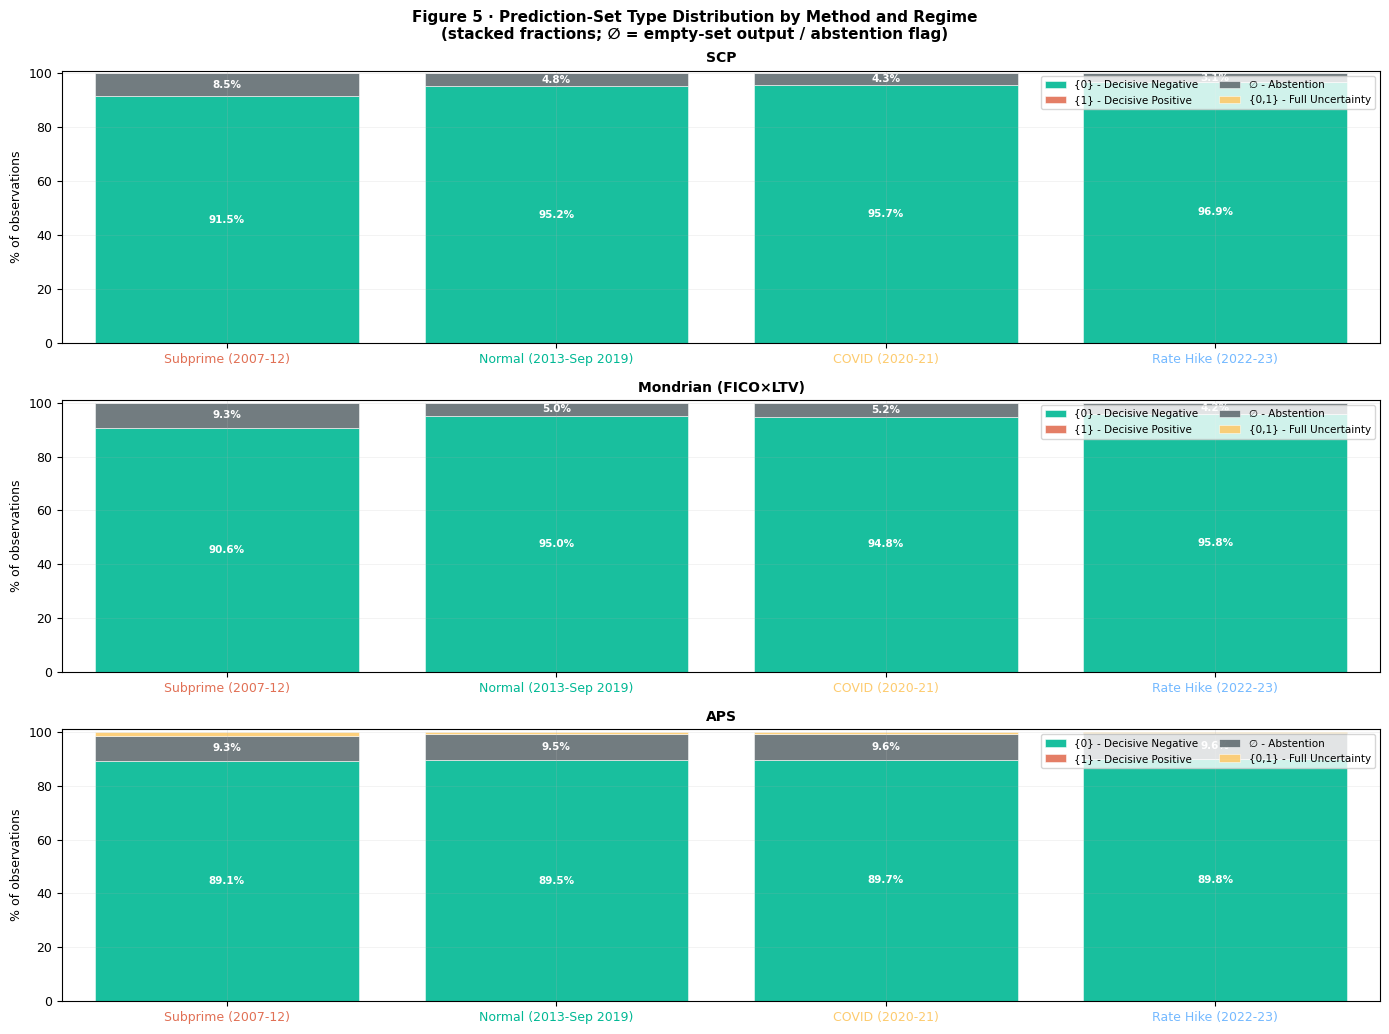

Figure 5 saved.


In [ ]:
# ── Figure 5: Prediction-set type distribution by method and regime ──────────
#
# Stacked bar chart showing fraction of observations in each set type.
# Reference: prediction-set type distributions are used here as a
# set-composition diagnostic. For APS, these are randomized coverage-analysis
# sets and should not be read as NB09 operational review rates.

ps_pd = ps_df.to_pandas()

ps_filt = ps_pd[
    ps_pd["method"].isin(PRIMARY_METHODS[:3]) &
    ps_pd["split"].isin(TEST_SPLITS)
].copy()

SET_TYPE_COLORS = {
    "singleton_0" : "#00b894",
    "singleton_1" : "#e17055",
    "empty"       : "#636e72",
    "both"        : "#fdcb6e",
}
SET_TYPE_LABELS = {
    "singleton_0" : "{0} - Decisive Negative",
    "singleton_1" : "{1} - Decisive Positive",
    "empty"       : "∅ - Abstention",
    "both"        : "{0,1} - Full Uncertainty",
}
SET_ORDER = ["singleton_0", "singleton_1", "empty", "both"]

n_methods = 3
n_splits  = len(TEST_SPLITS)
fig, axes = plt.subplots(n_methods, 1, figsize=(14, 3.5 * n_methods))
fig.suptitle(
    "Figure 5 · Prediction-Set Type Distribution by Method and Regime\n"
    "(stacked fractions; ∅ = empty-set output / abstention flag)",
    fontsize=11, fontweight="bold"
)

x_pos = np.arange(n_splits)

for ax, meth in zip(axes, PRIMARY_METHODS[:3]):
    bottom = np.zeros(n_splits)
    for st in SET_ORDER:
        vals = []
        for spl in TEST_SPLITS:
            subset = ps_filt[
                (ps_filt["method"] == meth) &
                (ps_filt["split"] == spl) &
                (ps_filt["set_type"] == st)
            ]
            vals.append(float(subset["fraction"].iloc[0]) * 100 if not subset.empty else 0.0)
        vals = np.array(vals)
        ax.bar(
            x_pos, vals, bottom=bottom, color=SET_TYPE_COLORS[st],
            label=SET_TYPE_LABELS[st], alpha=0.9, edgecolor="white", lw=0.4
        )
        for j, (v, b) in enumerate(zip(vals, bottom)):
            if v > 2.0:
                ax.text(
                    j, b + v / 2, f"{v:.1f}%",
                    ha="center", va="center",
                    fontsize=7.5, fontweight="bold", color="white"
                )
        bottom += vals

    ax.set_xlim(-0.5, n_splits - 0.5)
    ax.set_ylim(0, 101)
    ax.set_xticks(x_pos)
    ax.set_xticklabels([split_label(s) for s in TEST_SPLITS], fontsize=9)
    ax.set_ylabel("% of observations", fontsize=9)
    ax.set_title(f"{METHOD_LABELS[meth]}", fontsize=10, fontweight="bold")
    ax.legend(loc="upper right", fontsize=7.5, ncol=2)
    ax.grid(axis="y", alpha=0.2)

    for j, spl in enumerate(TEST_SPLITS):
        ax.get_xticklabels()[j].set_color(SPLIT_COLORS[spl])

fig.tight_layout()
fig.savefig(FIG_DIR / "fig5_prediction_set_types.png",
            bbox_inches="tight", dpi=FIG_DPI)
plt.show()
print("Figure 5 saved.")

# Underlying result data
fig5_source_df = ps_filt.copy()
fig5_source_df["method_label"] = fig5_source_df["method"].map(METHOD_LABELS)
fig5_source_df["split_label"] = fig5_source_df["split"].map(lambda x: split_label(x))
fig5_source_df["set_type_label"] = fig5_source_df["set_type"].map(SET_TYPE_LABELS)
fig5_source_df["fraction_pct"] = fig5_source_df["fraction"] * 100

In [ ]:
# Figure 5 underlying result data
display_full_df(
    fig5_source_df,
    title="Figure 5 underlying result data",
    columns=[
        "split", "split_label",
        "method", "method_label",
        "set_type", "set_type_label",
        "fraction", "fraction_pct",
    ],
    sort_by=["method", "split", "set_type"],
    round_digits=4,
)


=== Figure 5 underlying result data ===


,split,split_label,method,method_label,set_type,set_type_label,fraction,fraction_pct
0,test_covid,COVID (2020-21),aps,APS,both,"{0,1} - Full Uncertainty",0.0072,0.7235
1,test_covid,COVID (2020-21),aps,APS,empty,∅ - Abstention,0.0956,9.5550
2,test_covid,COVID (2020-21),aps,APS,singleton_0,{0} - Decisive Negative,0.8970,89.6962
3,test_covid,COVID (2020-21),aps,APS,singleton_1,{1} - Decisive Positive,0.0003,0.0252
4,test_normal,Normal (2013-Sep 2019),aps,APS,both,"{0,1} - Full Uncertainty",0.0096,0.9595
5,test_normal,Normal (2013-Sep 2019),aps,APS,empty,∅ - Abstention,0.0952,9.5167
6,test_normal,Normal (2013-Sep 2019),aps,APS,singleton_0,{0} - Decisive Negative,0.8946,89.4649
7,test_normal,Normal (2013-Sep 2019),aps,APS,singleton_1,{1} - Decisive Positive,0.0006,0.0589
8,test_rate_hike,Rate Hike (2022-23),aps,APS,both,"{0,1} - Full Uncertainty",0.0051,0.5063
9,test_rate_hike,Rate Hike (2022-23),aps,APS,empty,∅ - Abstention,0.0965,9.6452


         split            split_label            method        method_label    set_type           set_type_label  fraction  fraction_pct
    test_covid        COVID (2020-21)               aps                 APS        both {0,1} - Full Uncertainty    0.0072        0.7235
    test_covid        COVID (2020-21)               aps                 APS       empty           ∅ - Abstention    0.0956        9.5550
    test_covid        COVID (2020-21)               aps                 APS singleton_0  {0} - Decisive Negative    0.8970       89.6962
    test_covid        COVID (2020-21)               aps                 APS singleton_1  {1} - Decisive Positive    0.0003        0.0252
   test_normal Normal (2013-Sep 2019)               aps                 APS        both {0,1} - Full Uncertainty    0.0096        0.9595
   test_normal Normal (2013-Sep 2019)               aps                 APS       empty           ∅ - Abstention    0.0952        9.5167
   test_normal Normal (2013-Sep 2019)    

---
## Section 9 · Temporal Coverage Dynamics (Figures 6a-6b)

### Method and implementation boundary

Adaptive conformal inference (ACI; Gibbs & Candès, 2021) uses the published per-observation recursion

$$
\alpha_{t+1}
=
\alpha_t
+
\gamma\left(
\alpha
-
\mathbf{1}\{Y_t \notin \hat{C}_t(X_t)\}
\right).
$$

NB06 does not apply this update per loan-month observation. It aggregates row-level misses to realised calendar-month miscoverage, applies one update per observed month, and clips the working level to $[0,1]$. The resulting 196-step ACI sequence is therefore a **deployment adaptation** and is interpreted empirically rather than as a test or corollary of the published guarantee.

DtACI likewise uses the deterministic weighted-average aggregation of Gibbs & Candès (2024) as a template, but NB06 evaluates each expert at its own threshold and substitutes expert-specific monthly miscoverage for the paper's per-observation quantity. It is therefore also an empirical deployment adaptation.


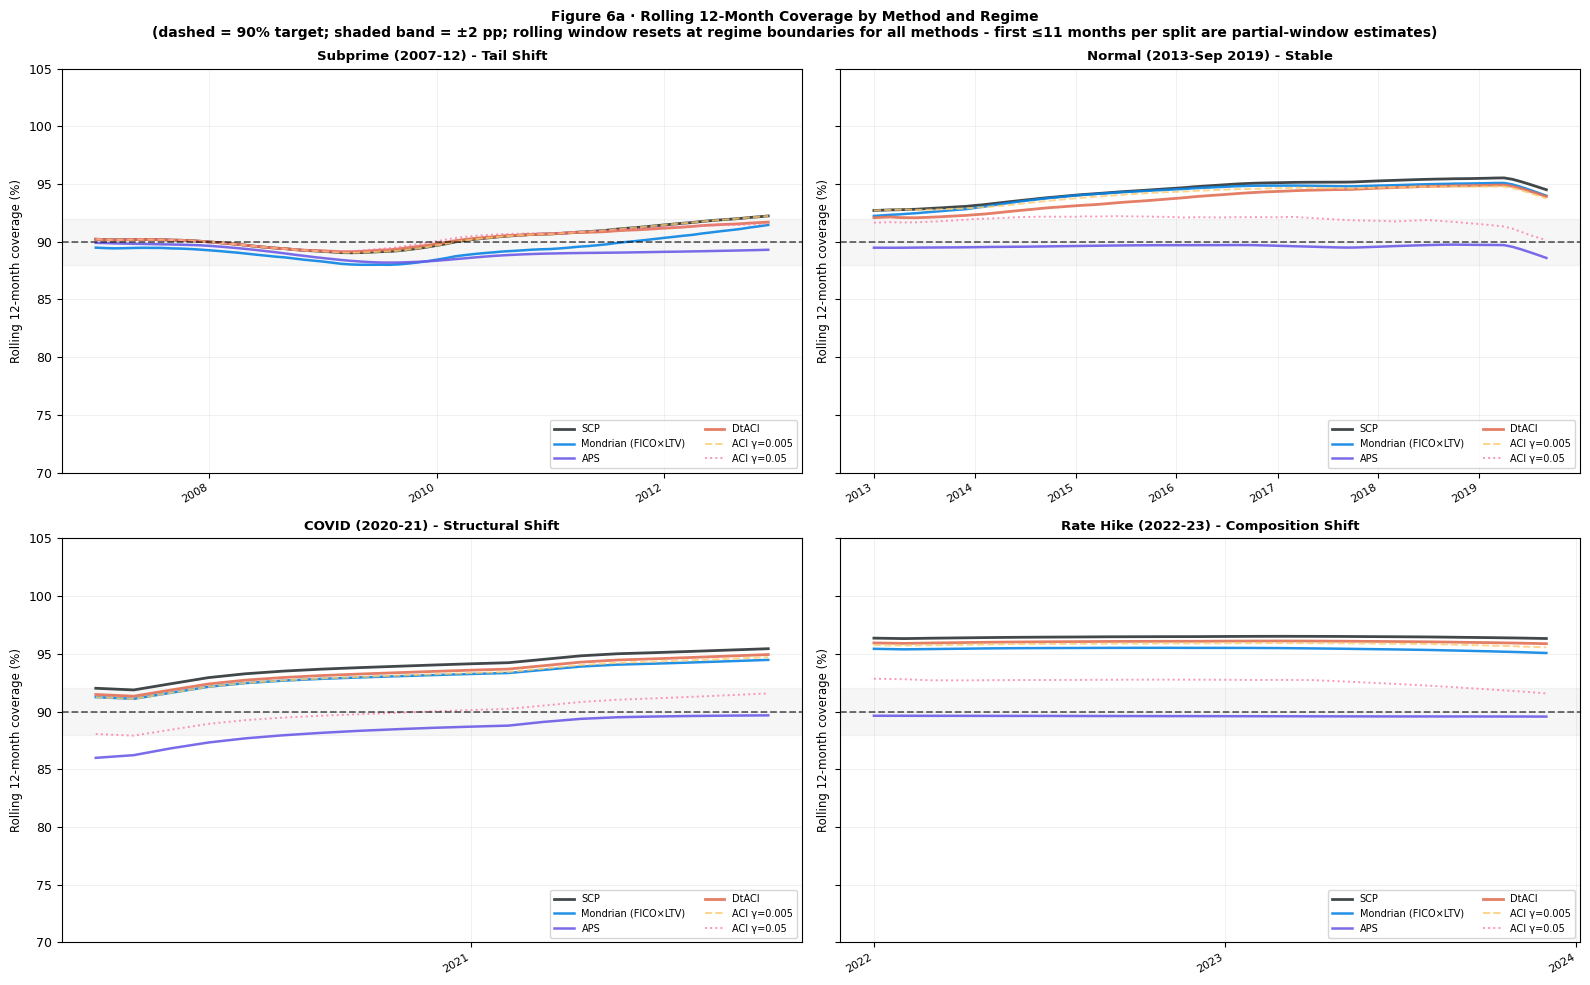

Figure 6a saved.


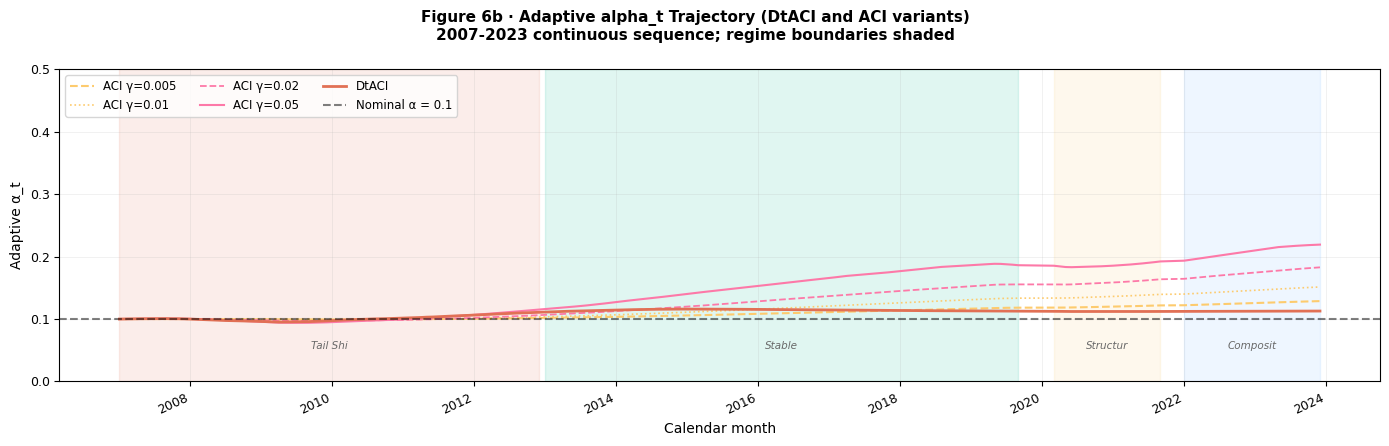

Figure 6b saved.


In [ ]:
# ── Figure 6a/b: Temporal coverage dynamics ─────────────────────────────────────
#
# Panel structure:
#   - Top row: rolling 12-month coverage by method, one panel per test regime
#   - Bottom: DtACI and ACI alpha_t trajectories over the full 2007-2023 horizon
#
# Reference: rolling coverage plots are a common temporal diagnostic in
# non-stationary conformal evaluation (Foygel Barber et al. 2023).

rc_pd = rc_df.to_pandas()
at_pd = at_df.to_pandas()

for df_ in [rc_pd, at_pd]:
    if df_["obs_month"].dtype == object:
        df_["obs_month"] = pd.to_datetime(df_["obs_month"])

TEMP_METHODS = ["scp", "mondrian_fico_ltv", "aps", "dtaci", "aci_g0_005", "aci_g0_05"]
TEMP_STYLES  = {
    "scp"              : dict(color="#2d3436", lw=2.0, ls="-",  alpha=0.9),
    "mondrian_fico_ltv": dict(color="#0984e3", lw=1.8, ls="-",  alpha=0.9),
    "aps"              : dict(color="#6c5ce7", lw=1.8, ls="-",  alpha=0.9),
    "dtaci"            : dict(color="#e17055", lw=2.0, ls="-",  alpha=0.9),
    "aci_g0_005"       : dict(color="#fdcb6e", lw=1.4, ls="--", alpha=0.8),
    "aci_g0_05"        : dict(color="#fd79a8", lw=1.4, ls=":",  alpha=0.8),
}

fig, axes = plt.subplots(2, 2, figsize=(16, 10), sharey=True)
fig.suptitle(
    "Figure 6a · Rolling 12-Month Coverage by Method and Regime\n"
    "(dashed = 90% target; shaded band = ±2 pp; "
    "rolling window resets at regime boundaries for all methods - "
    "first ≤11 months per split are partial-window estimates)",
    fontsize=10, fontweight="bold"
)
for ax, spl in zip(axes.flatten(), TEST_SPLITS):
    rc_spl = rc_pd[rc_pd["split"] == spl]
    for meth in TEMP_METHODS:
        rc_m = rc_spl[rc_spl["method"] == meth].sort_values("obs_month")
        if rc_m.empty:
            continue
        ax.plot(
            rc_m["obs_month"], rc_m[ROLLING_COV_COL] * 100,
            label=METHOD_LABELS.get(meth, meth),
            **TEMP_STYLES.get(meth, {})
        )
    ax.axhline(90, color="black", ls="--", lw=1.3, alpha=0.6)
    ax.axhspan(88, 92, color="grey", alpha=0.07)
    ax.set_title(f"{split_label(spl)} - {HEAT_MECH[spl]}",
                 fontsize=9.5, fontweight="bold")
    ax.set_ylabel("Rolling 12-month coverage (%)", fontsize=8.5)
    ax.set_ylim(70, 105)
    ax.legend(fontsize=7, ncol=2, loc="lower right")
    ax.xaxis.set_major_formatter(mpl.dates.DateFormatter("%Y"))
    ax.xaxis.set_major_locator(mpl.dates.YearLocator(2 if spl == "test_subprime" else 1))
    plt.setp(ax.get_xticklabels(), rotation=30, ha="right", fontsize=8)
    ax.grid(alpha=0.25)

fig.tight_layout()
fig.savefig(FIG_DIR / "fig6a_rolling_coverage.png", bbox_inches="tight", dpi=FIG_DPI)
plt.show()
print("Figure 6a saved.")

at_methods = sorted(at_pd["method"].unique())
fig2, ax2 = plt.subplots(figsize=(14, 4.5))
fig2.suptitle(
    "Figure 6b · Adaptive alpha_t Trajectory (DtACI and ACI variants)\n"
    "2007-2023 continuous sequence; regime boundaries shaded",
    fontsize=11, fontweight="bold"
)

at_styles = {
    "dtaci"     : dict(color="#e17055", lw=2.0, ls="-"),
    "aci_g0_005": dict(color="#fdcb6e", lw=1.5, ls="--"),
    "aci_g0_01" : dict(color="#fdcb6e", lw=1.2, ls=":"),
    "aci_g0_02" : dict(color="#fd79a8", lw=1.3, ls="--"),
    "aci_g0_05" : dict(color="#fd79a8", lw=1.5, ls="-"),
}

# Derive regime date extents from the rolling coverage data already in memory
REGIME_SPANS = [
    (
        spl,
        str(rc_pd[rc_pd["split"] == spl]["obs_month"].min()),
        str(rc_pd[rc_pd["split"] == spl]["obs_month"].max()),
        SPLIT_COLORS[spl],
    )
    for spl in TEST_SPLITS
    if not rc_pd[rc_pd["split"] == spl].empty
]
for spl, s, e, col in REGIME_SPANS:
    ax2.axvspan(pd.Timestamp(s), pd.Timestamp(e), color=col, alpha=0.12, zorder=0)
    ax2.text(
        pd.Timestamp(s) + (pd.Timestamp(e) - pd.Timestamp(s)) / 2,
        0.105, HEAT_MECH[spl][:8], ha="center", fontsize=7.5,
        color="dimgray", style="italic", transform=ax2.get_xaxis_transform()
    )

for meth in at_methods:
    parts = []
    for spl in TEST_SPLITS:
        part = at_pd[(at_pd["method"] == meth) & (at_pd["split"] == spl)].sort_values("obs_month")
        parts.append(part)
    combined = pd.concat(parts).sort_values("obs_month")
    if combined.empty:
        continue
    ax2.plot(
        combined["obs_month"], combined[ALPHA_T_COL],
        label=METHOD_LABELS.get(meth, meth),
        **at_styles.get(meth, dict(lw=1.3))
    )

ax2.axhline(ALPHA, color="black", ls="--", lw=1.5, alpha=0.5,
            label=f"Nominal α = {ALPHA}")
ax2.set_ylabel("Adaptive α_t", fontsize=10)
ax2.set_xlabel("Calendar month", fontsize=10)
ax2.set_ylim(0, max(0.5, at_pd[ALPHA_T_COL].quantile(0.99) * 1.1) if not at_pd.empty else 0.5)
ax2.legend(fontsize=8.5, ncol=3, loc="upper left")
ax2.grid(alpha=0.25)
ax2.xaxis.set_major_formatter(mpl.dates.DateFormatter("%Y"))
ax2.xaxis.set_major_locator(mpl.dates.YearLocator(2))
plt.setp(ax2.get_xticklabels(), rotation=25, ha="right", fontsize=9)

fig2.tight_layout()
fig2.savefig(FIG_DIR / "fig6b_alpha_t_trajectory.png", bbox_inches="tight", dpi=FIG_DPI)
plt.show()
print("Figure 6b saved.")

# Underlying result data
fig6a_source_df = rc_pd.copy()
fig6a_source_df["split_label"] = fig6a_source_df["split"].map(lambda x: split_label(x))
fig6a_source_df["method_label"] = fig6a_source_df["method"].map(lambda x: METHOD_LABELS.get(x, x))
fig6a_source_df["rolling_cov_pct"] = fig6a_source_df[ROLLING_COV_COL] * 100

fig6b_source_df = at_pd.copy()
fig6b_source_df["split_label"] = fig6b_source_df["split"].map(lambda x: split_label(x))
fig6b_source_df["method_label"] = fig6b_source_df["method"].map(lambda x: METHOD_LABELS.get(x, x))

In [ ]:
# Figure 6a/b underlying result data
display_full_df(
    fig6a_source_df,
    title="Figure 6a underlying result data (rolling coverage)",
    sort_by=["split", "method", "obs_month"],
    round_digits=6,
)

display_full_df(
    fig6b_source_df,
    title="Figure 6b underlying result data (adaptive alpha trajectories)",
    sort_by=["method", "split", "obs_month"],
    round_digits=6,
)


=== Figure 6a underlying result data (rolling coverage) ===


,split,method,method_family,obs_month,monthly_cov,rolling_12m,cum_cov,n,split_label,method_label,rolling_cov_pct
0,test_covid,aci_g0_005,Adaptive,2020-03-01,0.912384,0.912384,0.912384,10260910,COVID (2020-21),ACI γ=0.005,91.2384
1,test_covid,aci_g0_005,Adaptive,2020-04-01,0.909450,0.910923,0.910923,10173874,COVID (2020-21),ACI γ=0.005,91.0923
2,test_covid,aci_g0_005,Adaptive,2020-05-01,0.926960,0.916177,0.916177,9954844,COVID (2020-21),ACI γ=0.005,91.6177
3,test_covid,aci_g0_005,Adaptive,2020-06-01,0.937809,0.921471,0.921471,9847482,COVID (2020-21),ACI γ=0.005,92.1471
4,test_covid,aci_g0_005,Adaptive,2020-07-01,0.938109,0.924750,0.924750,9875482,COVID (2020-21),ACI γ=0.005,92.4750
5,test_covid,aci_g0_005,Adaptive,2020-08-01,0.938390,0.927016,0.927016,9986864,COVID (2020-21),ACI γ=0.005,92.7016
6,test_covid,aci_g0_005,Adaptive,2020-09-01,0.938583,0.928677,0.928677,10077552,COVID (2020-21),ACI γ=0.005,92.8677
7,test_covid,aci_g0_005,Adaptive,2020-10-01,0.938745,0.929953,0.929953,10179704,COVID (2020-21),ACI γ=0.005,92.9953
8,test_covid,aci_g0_005,Adaptive,2020-11-01,0.940226,0.931122,0.931122,10322645,COVID (2020-21),ACI γ=0.005,93.1122
9,test_covid,aci_g0_005,Adaptive,2020-12-01,0.942075,0.932256,0.932256,10473273,COVID (2020-21),ACI γ=0.005,93.2256


         split            method  method_family  obs_month  monthly_cov  rolling_12m  cum_cov        n            split_label        method_label  rolling_cov_pct
    test_covid        aci_g0_005       Adaptive 2020-03-01     0.912384     0.912384 0.912384 10260910        COVID (2020-21)         ACI γ=0.005          91.2384
    test_covid        aci_g0_005       Adaptive 2020-04-01     0.909450     0.910923 0.910923 10173874        COVID (2020-21)         ACI γ=0.005          91.0923
    test_covid        aci_g0_005       Adaptive 2020-05-01     0.926960     0.916177 0.916177  9954844        COVID (2020-21)         ACI γ=0.005          91.6177
    test_covid        aci_g0_005       Adaptive 2020-06-01     0.937809     0.921471 0.921471  9847482        COVID (2020-21)         ACI γ=0.005          92.1471
    test_covid        aci_g0_005       Adaptive 2020-07-01     0.938109     0.924750 0.924750  9875482        COVID (2020-21)         ACI γ=0.005          92.4750
    test_covid        

,split,method,obs_month,alpha_t,q_hat_t,split_label,method_label
0,test_covid,aci_g0_005,2020-03-01,0.118301,0.014012,COVID (2020-21),ACI γ=0.005
1,test_covid,aci_g0_005,2020-04-01,0.118363,0.014012,COVID (2020-21),ACI γ=0.005
2,test_covid,aci_g0_005,2020-05-01,0.118410,0.014012,COVID (2020-21),ACI γ=0.005
3,test_covid,aci_g0_005,2020-06-01,0.118545,0.014012,COVID (2020-21),ACI γ=0.005
4,test_covid,aci_g0_005,2020-07-01,0.118734,0.014012,COVID (2020-21),ACI γ=0.005
5,test_covid,aci_g0_005,2020-08-01,0.118924,0.014012,COVID (2020-21),ACI γ=0.005
6,test_covid,aci_g0_005,2020-09-01,0.119116,0.014012,COVID (2020-21),ACI γ=0.005
7,test_covid,aci_g0_005,2020-10-01,0.119309,0.014012,COVID (2020-21),ACI γ=0.005
8,test_covid,aci_g0_005,2020-11-01,0.119503,0.014012,COVID (2020-21),ACI γ=0.005
9,test_covid,aci_g0_005,2020-12-01,0.119704,0.014012,COVID (2020-21),ACI γ=0.005


         split     method  obs_month  alpha_t  q_hat_t            split_label method_label
    test_covid aci_g0_005 2020-03-01 0.118301 0.014012        COVID (2020-21)  ACI γ=0.005
    test_covid aci_g0_005 2020-04-01 0.118363 0.014012        COVID (2020-21)  ACI γ=0.005
    test_covid aci_g0_005 2020-05-01 0.118410 0.014012        COVID (2020-21)  ACI γ=0.005
    test_covid aci_g0_005 2020-06-01 0.118545 0.014012        COVID (2020-21)  ACI γ=0.005
    test_covid aci_g0_005 2020-07-01 0.118734 0.014012        COVID (2020-21)  ACI γ=0.005
    test_covid aci_g0_005 2020-08-01 0.118924 0.014012        COVID (2020-21)  ACI γ=0.005
    test_covid aci_g0_005 2020-09-01 0.119116 0.014012        COVID (2020-21)  ACI γ=0.005
    test_covid aci_g0_005 2020-10-01 0.119309 0.014012        COVID (2020-21)  ACI γ=0.005
    test_covid aci_g0_005 2020-11-01 0.119503 0.014012        COVID (2020-21)  ACI γ=0.005
    test_covid aci_g0_005 2020-12-01 0.119704 0.014012        COVID (2020-21)  ACI γ=0.005

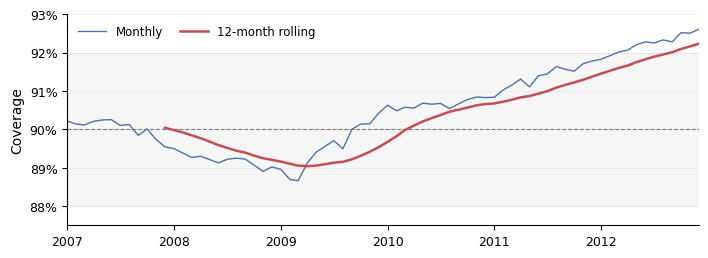

Figure 5.3 checks:
  Crisis pooled SCP coverage : 90.51%
  Full rolling breach       : 27 months (Jan 2008–Mar 2010)
  Rolling minimum           : 89.04% (Apr 2009)
  Monthly minimum           : 88.66% (Mar 2009)
  Final rolling coverage    : 92.23% (Dec 2012)
  Saved                     : /content/drive/MyDrive/master_thesis/results/nb07/figures/fig5_3_crisis_temporal_coverage.png
  Saved PDF                 : /content/drive/MyDrive/master_thesis/results/nb07/figures/fig5_3_crisis_temporal_coverage.pdf


In [ ]:
# ── Thesis Figure 4.3: Crisis temporal SCP coverage ──────────────────────────

FIG53_SPLIT  = "test_subprime"
FIG53_METHOD = "scp"
FULL_WINDOW  = 12

FIG53_MONTHLY_COLOR = "#4C72B0"
FIG53_ROLLING_COLOR = "#C44E52"

# Load only the authoritative upstream series required for this figure.
fig53_data = (
    pl.read_parquet(ROLLING_COV_PATH)
    .filter(
        (pl.col("split") == FIG53_SPLIT)
        & (pl.col("method") == FIG53_METHOD)
    )
    .select([
        "obs_month",
        "monthly_cov",
        "rolling_12m",
        "cum_cov",
        "n",
    ])
    .sort("obs_month")
    .to_pandas()
)

fig53_data["obs_month"] = pd.to_datetime(fig53_data["obs_month"])

# ---------------------------------------------------------------------------
# Structural contract
# ---------------------------------------------------------------------------

expected_months = pd.date_range(
    "2007-01-01",
    "2012-12-01",
    freq="MS",
)

assert len(fig53_data) == 72
assert pd.DatetimeIndex(fig53_data["obs_month"]).equals(expected_months)
assert fig53_data[["monthly_cov", "rolling_12m", "cum_cov", "n"]].notna().all().all()

# NB06 uses min_periods=1 within each regime, so the first 11 rolling values
# are partial windows.
fig53_data["rolling_12m_full"] = fig53_data["rolling_12m"].where(
    np.arange(len(fig53_data)) >= FULL_WINDOW - 1
)

fig53_full = (
    fig53_data
    .dropna(subset=["rolling_12m_full"])
    .reset_index(drop=True)
)

assert len(fig53_full) == 61
assert fig53_full.loc[0, "obs_month"] == pd.Timestamp("2007-12-01")


# ---------------------------------------------------------------------------
# Locked thesis-result checks
# ---------------------------------------------------------------------------

fig53_breach = fig53_full["rolling_12m_full"] < NOMINAL_COV
fig53_breach_idx = np.flatnonzero(fig53_breach.to_numpy())

# One uninterrupted 27-month breach: Jan 2008 through Mar 2010.
assert len(fig53_breach_idx) == 27
assert np.all(np.diff(fig53_breach_idx) == 1)
assert fig53_full.loc[fig53_breach_idx[0], "obs_month"] == pd.Timestamp("2008-01-01")
assert fig53_full.loc[fig53_breach_idx[-1], "obs_month"] == pd.Timestamp("2010-03-01")

# Recovery above nominal occurs in Apr 2010.
recovery_row = fig53_full.loc[fig53_breach_idx[-1] + 1]
assert recovery_row["obs_month"] == pd.Timestamp("2010-04-01")
assert recovery_row["rolling_12m_full"] >= NOMINAL_COV

rolling_min_row = fig53_full.loc[fig53_full["rolling_12m_full"].idxmin()]
monthly_min_row = fig53_data.loc[fig53_data["monthly_cov"].idxmin()]

assert rolling_min_row["obs_month"] == pd.Timestamp("2009-04-01")
assert round(rolling_min_row["rolling_12m_full"] * 100, 2) == 89.04

assert monthly_min_row["obs_month"] == pd.Timestamp("2009-03-01")
assert round(monthly_min_row["monthly_cov"] * 100, 2) == 88.66

# Full-window pooled SCP coverage and end-of-window rolling coverage.
pooled_cov = np.average(
    fig53_data["monthly_cov"],
    weights=fig53_data["n"],
)

assert round(pooled_cov * 100, 2) == 90.51
assert round(fig53_full.iloc[-1]["rolling_12m_full"] * 100, 2) == 92.23

# Guard against silently clipping the series if upstream results ever change.
assert fig53_data["monthly_cov"].min() * 100 >= 87.5
assert fig53_data["monthly_cov"].max() * 100 <= 93.0
assert fig53_full["rolling_12m_full"].min() * 100 >= 87.5
assert fig53_full["rolling_12m_full"].max() * 100 <= 93.0


# ---------------------------------------------------------------------------
# Plot
# ---------------------------------------------------------------------------

fig, ax = plt.subplots(figsize=(7.0, 2.5))

target_pct = NOMINAL_COV * 100
band_low   = target_pct - PRAC_SIG_PP
band_high  = target_pct + PRAC_SIG_PP

# Practical-significance band and nominal target.
ax.axhspan(
    band_low,
    band_high,
    color="0.5",
    alpha=0.07,
    zorder=0,
)

ax.axhline(
    target_pct,
    color="0.45",
    linestyle="--",
    linewidth=0.8,
    zorder=1,
)

# Monthly series: underlying unsmoothed temporal coverage.
ax.plot(
    fig53_data["obs_month"],
    fig53_data["monthly_cov"] * 100,
    color=FIG53_MONTHLY_COLOR,
    linewidth=1.0,
    label="Monthly",
    zorder=2,
)

# Full 12-month rolling series only.
ax.plot(
    fig53_full["obs_month"],
    fig53_full["rolling_12m_full"] * 100,
    color=FIG53_ROLLING_COLOR,
    linewidth=1.8,
    label="12-month rolling",
    zorder=3,
)

ax.set_ylabel("Coverage")

ax.set_ylim(87.5, 93.0)
ax.set_yticks([88, 89, 90, 91, 92, 93])
ax.yaxis.set_major_formatter(
    mpl.ticker.PercentFormatter(xmax=100, decimals=0)
)

ax.set_xlim(
    fig53_data["obs_month"].min(),
    fig53_data["obs_month"].max(),
)
ax.margins(x=0)

ax.xaxis.set_major_locator(mpl.dates.YearLocator())
ax.xaxis.set_major_formatter(mpl.dates.DateFormatter("%Y"))

ax.grid(False)
ax.grid(
    axis="y",
    alpha=0.2,
    linewidth=0.6,
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.legend(
    loc="upper left",
    frameon=False,
    ncol=2,
    fontsize=8.5,
    handlelength=2.4,
    columnspacing=1.4,
)

fig.tight_layout(pad=0.4)

fig53_path = FIG_DIR / "fig5_3_crisis_temporal_coverage.png"
fig53_pdf_path = fig53_path.with_suffix(".pdf")

# Raster copy for notebook / quick inspection
fig.savefig(
    fig53_path,
    bbox_inches="tight",
    dpi=FIG_DPI,
)

# Vector copy for the thesis
fig.savefig(
    fig53_pdf_path,
    bbox_inches="tight",
)

plt.show()

print("Figure 5.3 checks:")
print(f"  Crisis pooled SCP coverage : {pooled_cov:.2%}")
print(
    "  Full rolling breach       : "
    f"{len(fig53_breach_idx)} months "
    f"({fig53_full.loc[fig53_breach_idx[0], 'obs_month']:%b %Y}"
    "–"
    f"{fig53_full.loc[fig53_breach_idx[-1], 'obs_month']:%b %Y})"
)
print(
    "  Rolling minimum           : "
    f"{rolling_min_row['rolling_12m_full']:.2%} "
    f"({rolling_min_row['obs_month']:%b %Y})"
)
print(
    "  Monthly minimum           : "
    f"{monthly_min_row['monthly_cov']:.2%} "
    f"({monthly_min_row['obs_month']:%b %Y})"
)
print(
    "  Final rolling coverage    : "
    f"{fig53_full.iloc[-1]['rolling_12m_full']:.2%} "
    f"({fig53_full.iloc[-1]['obs_month']:%b %Y})"
)
print(f"  Saved                     : {fig53_path}")
print(f"  Saved PDF                 : {fig53_pdf_path}")

---
## Section 10 · Mechanism Attribution (Figures 7a–7b)

### The PSI-Coverage Dissociation Finding

As stated in the thesis, the Population Stability Index (PSI) is used here as a descriptive credit-risk drift diagnostic (Siddiqi, 2017; Yurdakul & Naranjo, 2020). The 0.10 and 0.25 bands are heuristic rather than calibrated statistical cutoffs.

The score PSI uses the *true-label SCP nonconformity score*. This makes it relevant to the quantity from which the SCP threshold is calibrated, but it is not a live outcome-free monitor and does not summarise all sources of non-exchangeability in the panel.

**Dissociation.** Figure 7a's left panel is contextual: marginal-coverage deviation rises with PSI across these four regimes. The dissociation concerns conditional reliability: Crisis has the lowest score PSI and widest SCP CovGap, whereas Rate Hike has the highest PSI and narrowest CovGap. COVID's PSI is 0.124, in the thesis's investigation band, despite the legacy "low PSI" annotation in Figure 7a. This endpoint pattern is descriptive.


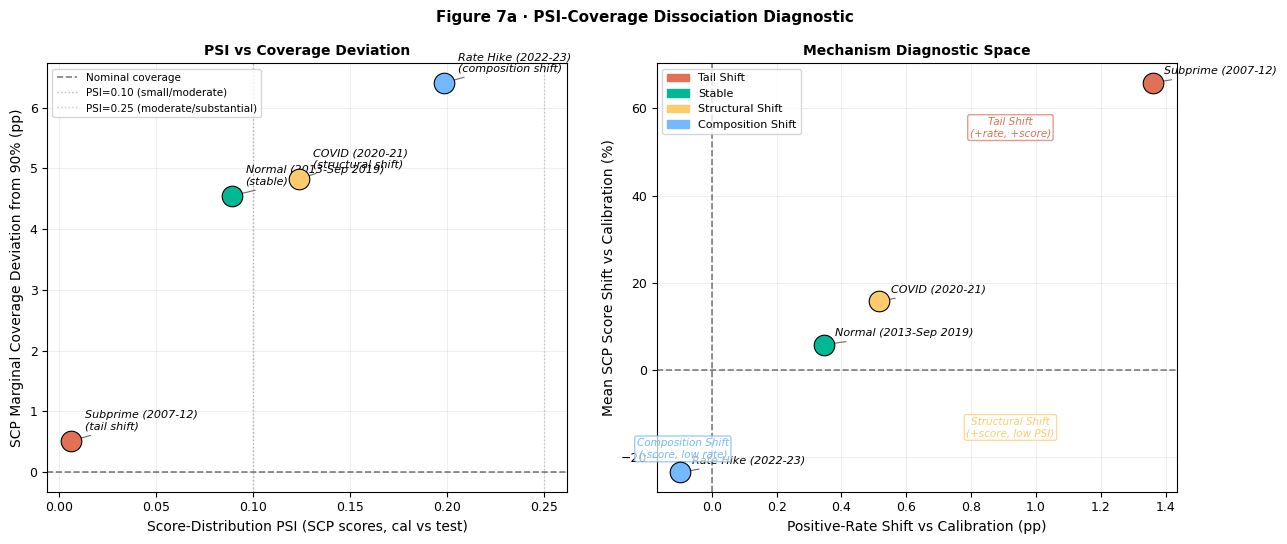

Figure 7a saved.


In [ ]:
# ── Figure 7a: PSI-Coverage dissociation scatter ─────────────────────────────
#
# Four-point scatter: PSI (x-axis) vs SCP marginal-coverage deviation (y-axis).
# Each point labelled with regime name and mechanism type.

psi_vals  = [MECH_ATTR["splits"][s]["psi"] for s in TEST_SPLITS]
score_dev = [_get_val(metrics_df, s, "scp", "dev_from_nom_pp") for s in TEST_SPLITS]
mech_type = [MECH_ATTR["splits"][s]["mechanism_type"] for s in TEST_SPLITS]
pos_rate  = [MECH_ATTR["splits"][s]["positive_rate_pct"] for s in TEST_SPLITS]
mean_sc_s = [MECH_ATTR["splits"][s]["mean_score_shift_pct"] for s in TEST_SPLITS]

MECH_COLOR_MAP = {
    "tail_shift"       : "#e17055",
    "stable"           : "#00b894",
    "structural_shift" : "#fdcb6e",
    "composition_shift": "#74b9ff",
}

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
fig.suptitle(
    "Figure 7a · PSI-Coverage Dissociation Diagnostic",
    fontsize=11, fontweight="bold"
)

ax = axes[0]
for i, spl in enumerate(TEST_SPLITS):
    col = MECH_COLOR_MAP.get(mech_type[i], "#636e72")
    ax.scatter(psi_vals[i], score_dev[i], s=220, color=col,
               zorder=5, edgecolors="black", lw=0.8)
    ax.annotate(
        f"{split_label(spl)}\n({mech_type[i].replace('_', ' ')})",
        (psi_vals[i], score_dev[i]),
        xytext=(10, 8), textcoords="offset points",
        fontsize=8, style="italic",
        arrowprops=dict(arrowstyle="->", color="dimgray", lw=0.8),
    )
ax.axhline(0, color="black", ls="--", lw=1.2, alpha=0.5, label="Nominal coverage")
ax.axvline(0.10, color="grey", ls=":", lw=1, alpha=0.6, label="PSI=0.10 (small/moderate)")
ax.axvline(0.25, color="grey", ls=":", lw=1, alpha=0.4, label="PSI=0.25 (moderate/substantial)")
ax.set_xlabel("Score-Distribution PSI (SCP scores, cal vs test)", fontsize=10)
ax.set_ylabel("SCP Marginal Coverage Deviation from 90% (pp)", fontsize=10)
ax.set_title("PSI vs Coverage Deviation", fontsize=10, fontweight="bold")
ax.legend(fontsize=7.5)
ax.grid(alpha=0.3)

ax2 = axes[1]
for i, spl in enumerate(TEST_SPLITS):
    col = MECH_COLOR_MAP.get(mech_type[i], "#636e72")
    pr_shift = pos_rate[i] - CP_MANIFEST["positive_rate_pct"]["calibration"]
    ms_shift = float(mean_sc_s[i])
    ax2.scatter(pr_shift, ms_shift, s=220, color=col,
                zorder=5, edgecolors="black", lw=0.8)
    ax2.annotate(
        f"{split_label(spl)}",
        (pr_shift, ms_shift),
        xytext=(8, 6), textcoords="offset points",
        fontsize=8, style="italic",
        arrowprops=dict(arrowstyle="->", color="dimgray", lw=0.8),
    )

ax2.axhline(0, color="black", ls="--", lw=1.2, alpha=0.5)
ax2.axvline(0, color="black", ls="--", lw=1.2, alpha=0.5)
ax2.set_xlabel("Positive-Rate Shift vs Calibration (pp)", fontsize=10)
ax2.set_ylabel("Mean SCP Score Shift vs Calibration (%)", fontsize=10)
ax2.set_title("Mechanism Diagnostic Space", fontsize=10, fontweight="bold")

for txt, xy, c in [
    ("Tail Shift\n(+rate, +score)", (0.68, 0.85), "#e17055"),
    ("Composition Shift\n(-score, low rate)", (0.05, 0.1), "#74b9ff"),
    ("Structural Shift\n(+score, low PSI)", (0.68, 0.15), "#fdcb6e"),
]:
    ax2.text(
        *xy, txt, transform=ax2.transAxes, ha="center", va="center",
        fontsize=7.5, color=c, style="italic",
        bbox=dict(boxstyle="round,pad=0.2", fc="white", ec=c, alpha=0.7)
    )

ax2.grid(alpha=0.3)
handles = [mpatches.Patch(color=MECH_COLOR_MAP[k], label=k.replace("_", " ").title())
           for k in MECH_COLOR_MAP]
ax2.legend(handles=handles, fontsize=8, loc="upper left")

fig.tight_layout()
fig.savefig(FIG_DIR / "fig7a_psi_dissociation.png", bbox_inches="tight", dpi=FIG_DPI)
plt.show()
print("Figure 7a saved.")

# Underlying result data
fig7a_source_df = pd.DataFrame([
    {
        "split": spl,
        "split_label": split_label(spl),
        "mechanism_type": mech_type[i],
        "psi": psi_vals[i],
        "scp_marginal_cov_dev_pp": score_dev[i],
        "positive_rate_pct": pos_rate[i],
        "positive_rate_shift_pp_vs_cal": pos_rate[i] - CP_MANIFEST["positive_rate_pct"]["calibration"],
        "mean_scp_score_shift_pct": float(mean_sc_s[i]),
    }
    for i, spl in enumerate(TEST_SPLITS)
])

In [ ]:
# Figure 7a/b underlying result data
display_full_df(
    fig7a_source_df,
    title="Figure 7a underlying result data",
    sort_by=["split"],
    round_digits=6,
)


=== Figure 7a underlying result data ===


,split,split_label,mechanism_type,psi,scp_marginal_cov_dev_pp,positive_rate_pct,positive_rate_shift_pp_vs_cal,mean_scp_score_shift_pct
0,test_covid,COVID (2020-21),structural_shift,0.123960,4.827112,1.661349,0.517205,15.7805
1,test_normal,Normal (2013-Sep 2019),stable,0.089120,4.548225,1.488735,0.344591,5.8160
2,test_rate_hike,Rate Hike (2022-23),composition_shift,0.198828,6.408742,1.047697,-0.096447,-23.3978
3,test_subprime,Subprime (2007-12),tail_shift,0.006231,0.514689,2.505403,1.361259,65.8490


         split            split_label    mechanism_type      psi  scp_marginal_cov_dev_pp  positive_rate_pct  positive_rate_shift_pp_vs_cal  mean_scp_score_shift_pct
    test_covid        COVID (2020-21)  structural_shift 0.123960                 4.827112           1.661349                       0.517205                   15.7805
   test_normal Normal (2013-Sep 2019)            stable 0.089120                 4.548225           1.488735                       0.344591                    5.8160
test_rate_hike    Rate Hike (2022-23) composition_shift 0.198828                 6.408742           1.047697                      -0.096447                  -23.3978
 test_subprime     Subprime (2007-12)        tail_shift 0.006231                 0.514689           2.505403                       1.361259                   65.8490


### Mechanism Attribution Table

The following table formalises the regime-mechanism mapping used throughout the thesis.
The mechanism labels are as stated an a-priori taxonomy: the same PSI/score pattern could in principle arise from
multiple data-generating processes. CP validity results characterise coverage under
distributional assumptions (exchangeability or bounded deviation from it).


In [ ]:
# ── Mechanism attribution table ───────────────────────────────────────────────
mech_rows = []
for spl in TEST_SPLITS:
    m = MECH_ATTR["splits"][spl]
    scp_mc  = _get_val(metrics_df, spl, "scp",            "marginal_cov")
    mond_mc = _get_val(metrics_df, spl, "mondrian_fico_ltv","marginal_cov")
    aps_mc  = _get_val(metrics_df, spl, "aps",            "marginal_cov")
    dtaci_mc= _get_val(metrics_df, spl, "dtaci",          "marginal_cov")
    cov_y1  = _get_val(metrics_df, spl, "scp",            "cov_y1")
    cg      = _get_val(metrics_df, spl, "scp",            "covgap_pp")
    mech_tbl = {
        "Regime"          : split_label(spl),
        "Mechanism"       : m["mechanism_type"].replace("_"," ").title(),
        "PSI (score)"     : f"{m['psi']:.4f}",
        "E[score] shift"  : f"{float(m['mean_score_shift_pct']):+.1f}%",
        "Pos. rate"       : f"{m['positive_rate_pct']:.2f}%",
        "SCP MC"          : f"{scp_mc*100:.2f}%" if not np.isnan(scp_mc) else "-",
        "SCP Cov(y=1)"    : f"{cov_y1*100:.6f}%" if not np.isnan(cov_y1) else "-",
        "SCP CovGap (pp)" : f"{cg:.2f}" if not np.isnan(cg) else "-",
        "Mondrian MC"     : f"{mond_mc*100:.2f}%" if not np.isnan(mond_mc) else "-",
        "APS MC"          : f"{aps_mc*100:.2f}%" if not np.isnan(aps_mc) else "-",
        "DtACI MC"        : f"{dtaci_mc*100:.2f}%" if not np.isnan(dtaci_mc) else "-",
    }
    mech_rows.append(mech_tbl)

mech_tbl_df = pd.DataFrame(mech_rows)
print(mech_tbl_df.to_string(index=False))
print()

mech_tbl_df.to_csv(NB07_OUT_DIR / "nb07_mechanism_attribution.csv", index=False)
print("\nMechanism attribution table saved.")

                Regime         Mechanism PSI (score) E[score] shift Pos. rate SCP MC SCP Cov(y=1) SCP CovGap (pp) Mondrian MC APS MC DtACI MC
    Subprime (2007-12)        Tail Shift      0.0062         +65.8%     2.51% 90.51%    0.000700%           79.69      89.50% 88.99%   90.42%
Normal (2013-Sep 2019)            Stable      0.0891          +5.8%     1.49% 94.55%    0.000210%           47.07      94.27% 89.46%   93.81%
       COVID (2020-21)  Structural Shift      0.1240         +15.8%     1.66% 94.83%    0.000000%           31.97      93.90% 89.14%   94.30%
   Rate Hike (2022-23) Composition Shift      0.1988         -23.4%     1.05% 96.41%    0.000063%           24.94      95.29% 89.58%   95.98%


Mechanism attribution table saved.


### Regime Classification Evidence

The mechanism labels are again an a-priori taxonomy, not causal identifications. The table reports three diagnostics that bear on them: score PSI, mean-score shift, and the positive rate from NB06's 2% mechanism-diagnostic sample. The thesis's canonical regime-composition rates are the full-panel values in Table 3.1, so the small numerical differences are sample differences rather than conflicting results.

**Feature-level PSI cross-reference (NB02 §5.9):** NB02 reports label-free PSI for selected origination features on a 10% sample of all active loan-months, a slightly broader population than the model panel. Crisis has the smallest PSI of the four test windows on each reported numeric feature, but its note-rate PSI is 0.1364, so the monitor is not silent there.

The evidence therefore supports an **endpoint dissociation** between drift magnitude and conditional reliability, not a general inverse relationship or identification of a regime mechanism. The printed mechanism-basis phrases below should be read only as legacy consistency heuristics. The computed diagnostics, not those causal phrases, are the evidence.

In [ ]:
# ── Regime classification evidence table ──────────────────────────────────────
#
# Presents each regime's mechanism label next to the computed statistics that bear on it.
# The label is a hypothesis.
# Data sources:
#   - PSI, psi_interpretation, mean_score_shift_pct, positive_rate_pct : MECH_ATTR (NB06 §4)
#   - SCP marginal coverage, Cov(y=1), CovGap                          : coverage_metrics (NB06 §3)
#   - test_normal forward-window contamination                         : panel_manifest (NB03 Check 2b)
#
# PSI bands (heuristic only; thesis terminology in parentheses):
#   < 0.10    → small        (negligible)
#   0.10-0.25 → moderate     (investigation)
#   > 0.25    → substantial  (action)

# Build year ranges dynamically from cp_manifest score_splits
_split_yr_map = {
    split_name: info['obs_years']
    for split_name, info in CP_MANIFEST['score_splits'].items()
}
REGIME_PERIODS = {
    spl: f"{min(_split_yr_map.get(spl, [0]))}\u2013{max(_split_yr_map.get(spl, [0]))}"
    for spl in TEST_SPLITS
}

MECHANISM_LABEL_BASIS = {
    'tail_shift'       : ('Low PSI + elevated positive rate + large mean score increase '
                          '→ high-score turnover with little bulk distribution shift'),
    'stable'           : ('A-priori hypothesis: below-threshold score PSI + mild mean score '
                          'increase + near-baseline positive rate would suggest a near-exchangeable '
                          'score distribution. The realised SCP coverage and the NB03 forward-window '
                          'contamination are reported alongside (see notes); both qualify this label '
                          'for test_normal.'),
    'structural_shift' : ('Moderate PSI + elevated score + positive rate above calibration '
                          '+ COVID forbearance (CARES Act) suppresses REO progression '
                          '→ P(Y|X) altered by policy intervention, not score drift alone (CFPB & CSBS, 2020; FHFA OIG, 2020)'),
    'composition_shift': ('Highest PSI + compressed score distribution (negative mean shift) '
                          '+ lowest positive rate → portfolio composition change '
                          'dominates; fewer high-risk loans in active population'),
}

_cal_pos_rate = CP_MANIFEST["positive_rate_pct"]["calibration"]

evidence_rows = []
for split_name in TEST_SPLITS:
    m = MECH_ATTR['splits'][split_name]

    # Coverage metrics for this split
    scp_mc  = _get_val(metrics_df, split_name, 'scp', 'marginal_cov')
    scp_cy1 = _get_val(metrics_df, split_name, 'scp', 'cov_y1')
    scp_cg  = _get_val(metrics_df, split_name, 'scp', 'covgap_pp')
    aps_mc  = _get_val(metrics_df, split_name, 'aps', 'marginal_cov')

    psi       = float(m['psi'])
    psi_class = m['psi_interpretation']
    score_sft = float(m['mean_score_shift_pct'])
    pos_rate  = float(m['positive_rate_pct'])
    mech      = m['mechanism_type']

    evidence_rows.append({
        'Regime'               : split_label(split_name),
        'Period'               : REGIME_PERIODS[split_name],
        'Mechanism label'      : mech.replace('_', ' ').title(),
        'PSI (score dist.)'    : f'{psi:.4f}',
        'PSI class'            : psi_class,
        'E[score] shift'       : f'{score_sft:+.1f}%',
        'Pos. rate (%)'        : f'{pos_rate:.2f}%',
        f'Cal. baseline ({_cal_pos_rate:.2f}%)': (
            '↑' if pos_rate > _cal_pos_rate
            else '↓' if pos_rate < _cal_pos_rate
            else '≈'
        ),
        'SCP MC (%)'           : f'{scp_mc*100:.2f}%' if not np.isnan(scp_mc) else '-',
        'SCP Cov(y=1) (%)'     : f'{scp_cy1*100:.4f}%' if not np.isnan(scp_cy1) else '-',
        'SCP CovGap (pp)'      : f'{scp_cg:.2f}' if not np.isnan(scp_cg) else '-',
    })

evidence_df = pd.DataFrame(evidence_rows)

print('=== Regime Classification Evidence Table ===\n')
print(evidence_df.to_string(index=False))

print('\nPrimary classification basis per mechanism label:')
for mech_key, basis in MECHANISM_LABEL_BASIS.items():
    print(f'\n  [{mech_key.replace("_", " ").title()}]')
    print(f'  {basis}')

evidence_df.to_csv(NB07_OUT_DIR / 'nb07_regime_classification_evidence.csv', index=False)
print('\nRegime classification evidence saved.')

=== Regime Classification Evidence Table ===

                Regime    Period   Mechanism label PSI (score dist.)            PSI class E[score] shift Pos. rate (%) Cal. baseline (1.14%) SCP MC (%) SCP Cov(y=1) (%) SCP CovGap (pp)
    Subprime (2007-12) 2007–2012        Tail Shift            0.0062        small (<0.10)         +65.8%         2.51%                     ↑     90.51%          0.0007%           79.69
Normal (2013-Sep 2019) 2013–2019            Stable            0.0891        small (<0.10)          +5.8%         1.49%                     ↑     94.55%          0.0002%           47.07
       COVID (2020-21) 2020–2021  Structural Shift            0.1240 moderate (0.10-0.25)         +15.8%         1.66%                     ↑     94.83%          0.0000%           31.97
   Rate Hike (2022-23) 2022–2023 Composition Shift            0.1988 moderate (0.10-0.25)         -23.4%         1.05%                     ↓     96.41%          0.0001%           24.94

Primary classification basis

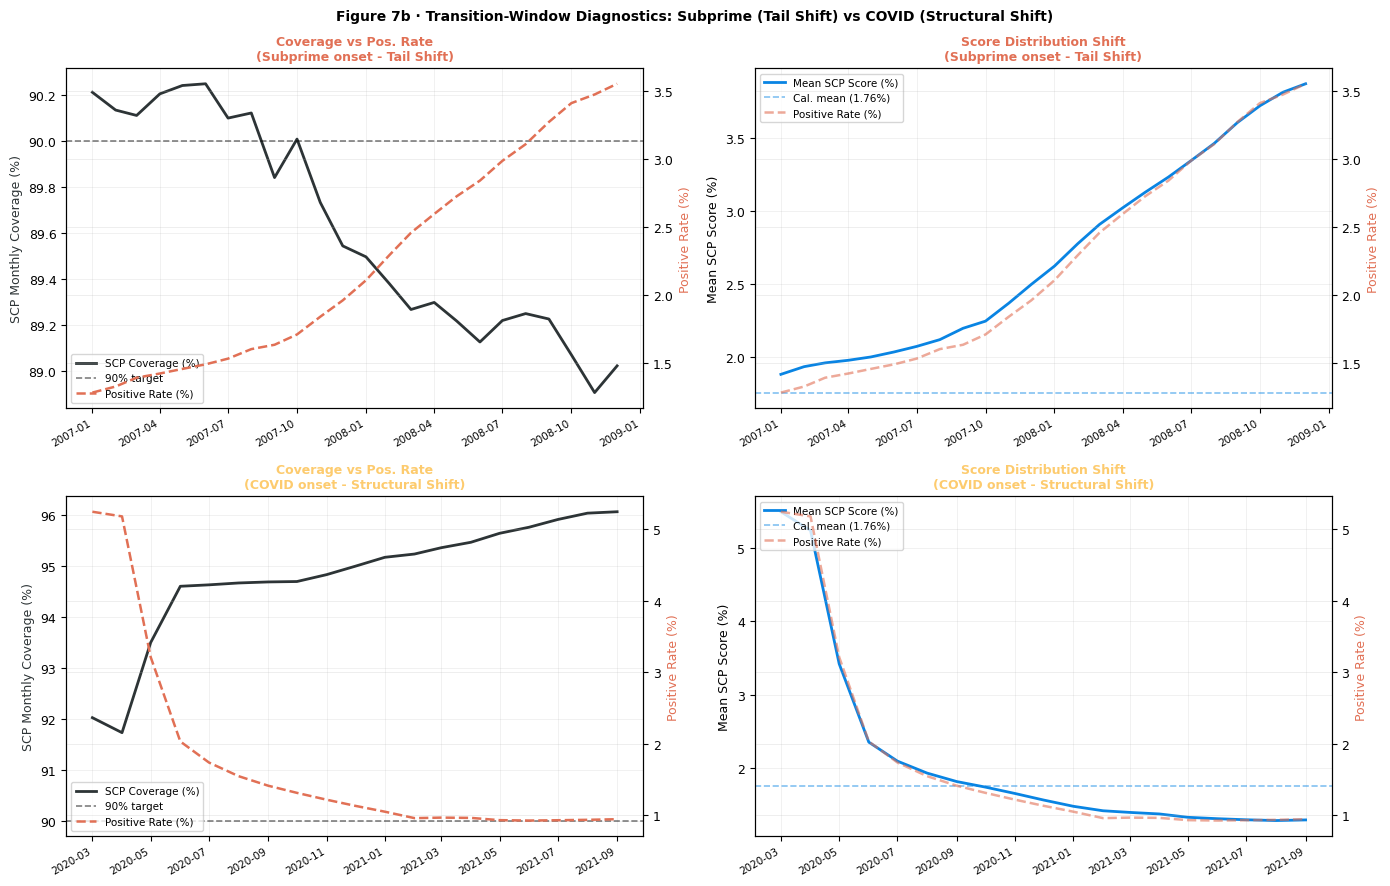

Figure 7b saved.


In [ ]:
# ── Figure 7b: Transition-window diagnostics - Crisis and COVID onsets ───────
#
# Two onset windows shown side-by-side:
#   Left: Crisis (2007) - tail-shift hypothesis; low PSI and gradual positive-rate rise
#   Right: COVID (2020) - structural-shift hypothesis; higher PSI and abrupt
#          positive-rate spike followed by policy-affected realised transitions
#
# The panels contrast two observable onset patterns. The regime labels are
# a-priori design hypotheses rather than causal identifications.

_mean_score_block = CP_MANIFEST.get("mean_score_scp", {})
assert "calibration" in _mean_score_block, (
    "cp_manifest['mean_score_scp'] has no 'calibration' key; "
    "cannot draw the calibration-mean reference line in Figure 7b."
)
cal_mean_sc = _mean_score_block["calibration"] * 100

def _build_onset_df(key):
    td = MECH_ATTR["transition_diagnostics"][key]
    return (
        [pd.Timestamp(r["obs_month"]) for r in td],
        [r["pos_rate"] * 100         for r in td],
        [r["mean_score"] * 100       for r in td],
        [r["scp_coverage"] * 100     for r in td],
    )

def _plot_onset_pair(ax_cov, ax_score, months, pos_r, mean_sc, scp_cov, title_suffix, mech_color):
    ax_cov.plot(months, scp_cov, color="#2d3436", lw=2.0, label="SCP Coverage (%)")
    ax_cov.axhline(90, color="black", ls="--", lw=1.2, alpha=0.5, label="90% target")
    ax_cov.set_ylabel("SCP Monthly Coverage (%)", fontsize=9, color="#2d3436")
    ax_cov_r = ax_cov.twinx()
    ax_cov_r.plot(months, pos_r, color="#e17055", lw=1.8, ls="--", label="Positive Rate (%)")
    ax_cov_r.set_ylabel("Positive Rate (%)", fontsize=9, color="#e17055")
    ax_cov.set_title(f"Coverage vs Pos. Rate\n({title_suffix})", fontsize=9, fontweight="bold",
                     color=mech_color)
    lines1, labels1 = ax_cov.get_legend_handles_labels()
    lines2, labels2 = ax_cov_r.get_legend_handles_labels()
    ax_cov.legend(lines1 + lines2, labels1 + labels2, fontsize=7.5, loc="lower left")
    ax_cov.grid(alpha=0.25)
    ax_cov.xaxis.set_major_formatter(mpl.dates.DateFormatter("%Y-%m"))
    plt.setp(ax_cov.get_xticklabels(), rotation=30, ha="right", fontsize=7.5)

    ax_score.plot(months, mean_sc, color="#0984e3", lw=2.0, label="Mean SCP Score (%)")
    ax_score.axhline(cal_mean_sc, color="#0984e3", ls="--", lw=1.2, alpha=0.5,
                label=f"Cal. mean ({cal_mean_sc:.2f}%)")
    ax_score.set_ylabel("Mean SCP Score (%)", fontsize=9)
    ax_score_r = ax_score.twinx()
    ax_score_r.plot(months, pos_r, color="#e17055", lw=1.8, ls="--", alpha=0.6,
                    label="Positive Rate (%)")
    ax_score_r.set_ylabel("Positive Rate (%)", fontsize=9, color="#e17055")
    ax_score.set_title(f"Score Distribution Shift\n({title_suffix})", fontsize=9,
                       fontweight="bold", color=mech_color)
    lines1, labels1 = ax_score.get_legend_handles_labels()
    lines2, labels2 = ax_score_r.get_legend_handles_labels()
    ax_score.legend(lines1 + lines2, labels1 + labels2, fontsize=7.5, loc="upper left")
    ax_score.grid(alpha=0.25)
    ax_score.xaxis.set_major_formatter(mpl.dates.DateFormatter("%Y-%m"))
    plt.setp(ax_score.get_xticklabels(), rotation=30, ha="right", fontsize=7.5)

months_sub, pos_r_sub, mean_sc_sub, scp_cov_sub = _build_onset_df("subprime_onset")
months_cov, pos_r_cov, mean_sc_cov, scp_cov_cov = _build_onset_df("covid_onset")

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
_psi_sub = MECH_ATTR["splits"]["test_subprime"]["psi"]
fig.suptitle(
    "Figure 7b · Transition-Window Diagnostics: Subprime (Tail Shift) vs COVID (Structural Shift)",
    fontsize=10, fontweight="bold"
)

_plot_onset_pair(axes[0, 0], axes[0, 1],
                 months_sub, pos_r_sub, mean_sc_sub, scp_cov_sub,
                 "Subprime onset - Tail Shift", "#e17055")
_plot_onset_pair(axes[1, 0], axes[1, 1],
                 months_cov, pos_r_cov, mean_sc_cov, scp_cov_cov,
                 "COVID onset - Structural Shift", "#fdcb6e")

fig.tight_layout()
fig.savefig(FIG_DIR / "fig7b_transition_diagnostics.png", bbox_inches="tight", dpi=FIG_DPI)
plt.show()
print("Figure 7b saved.")

# Underlying result data (both onsets)
fig7b_source_df = pd.DataFrame([
    {"onset": "subprime", "obs_month": m, "positive_rate_pct": pr,
     "mean_scp_score_pct": ms, "scp_coverage_pct": sc,
     "calibration_mean_scp_score_pct": cal_mean_sc}
    for m, pr, ms, sc in zip(months_sub, pos_r_sub, mean_sc_sub, scp_cov_sub)
] + [
    {"onset": "covid", "obs_month": m, "positive_rate_pct": pr,
     "mean_scp_score_pct": ms, "scp_coverage_pct": sc,
     "calibration_mean_scp_score_pct": cal_mean_sc}
    for m, pr, ms, sc in zip(months_cov, pos_r_cov, mean_sc_cov, scp_cov_cov)
])

In [ ]:
# Figure 7b underlying result data
display_full_df(
    fig7b_source_df,
    title="Figure 7b underlying result data",
    sort_by=["onset", "obs_month"],
    round_digits=6,
)


=== Figure 7b underlying result data ===


,onset,obs_month,positive_rate_pct,mean_scp_score_pct,scp_coverage_pct,calibration_mean_scp_score_pct
0,covid,2020-03-01,5.243073,5.486167,92.018710,1.756893
1,covid,2020-04-01,5.177880,5.232152,91.724578,1.756893
2,covid,2020-05-01,3.209091,3.419381,93.493509,1.756893
3,covid,2020-06-01,2.028529,2.354789,94.597086,1.756893
4,covid,2020-07-01,1.733718,2.096454,94.625295,1.756893
5,covid,2020-08-01,1.542977,1.934251,94.662088,1.756893
6,covid,2020-09-01,1.409420,1.819237,94.682409,1.756893
7,covid,2020-10-01,1.309567,1.743846,94.690406,1.756893
8,covid,2020-11-01,1.214136,1.657009,94.825202,1.756893
9,covid,2020-12-01,1.128138,1.567894,94.990382,1.756893


   onset  obs_month  positive_rate_pct  mean_scp_score_pct  scp_coverage_pct  calibration_mean_scp_score_pct
   covid 2020-03-01           5.243073            5.486167         92.018710                        1.756893
   covid 2020-04-01           5.177880            5.232152         91.724578                        1.756893
   covid 2020-05-01           3.209091            3.419381         93.493509                        1.756893
   covid 2020-06-01           2.028529            2.354789         94.597086                        1.756893
   covid 2020-07-01           1.733718            2.096454         94.625295                        1.756893
   covid 2020-08-01           1.542977            1.934251         94.662088                        1.756893
   covid 2020-09-01           1.409420            1.819237         94.682409                        1.756893
   covid 2020-10-01           1.309567            1.743846         94.690406                        1.756893
   covid 2020-11-01

---
## Section 11 · Exploratory Static-Method Trade-off View

Figure 8 is retained only as an exploratory scatter. Despite the legacy "Pareto frontier" title, no Pareto frontier is estimated. Its empty-set axis is a coverage-analysis set-composition measure.

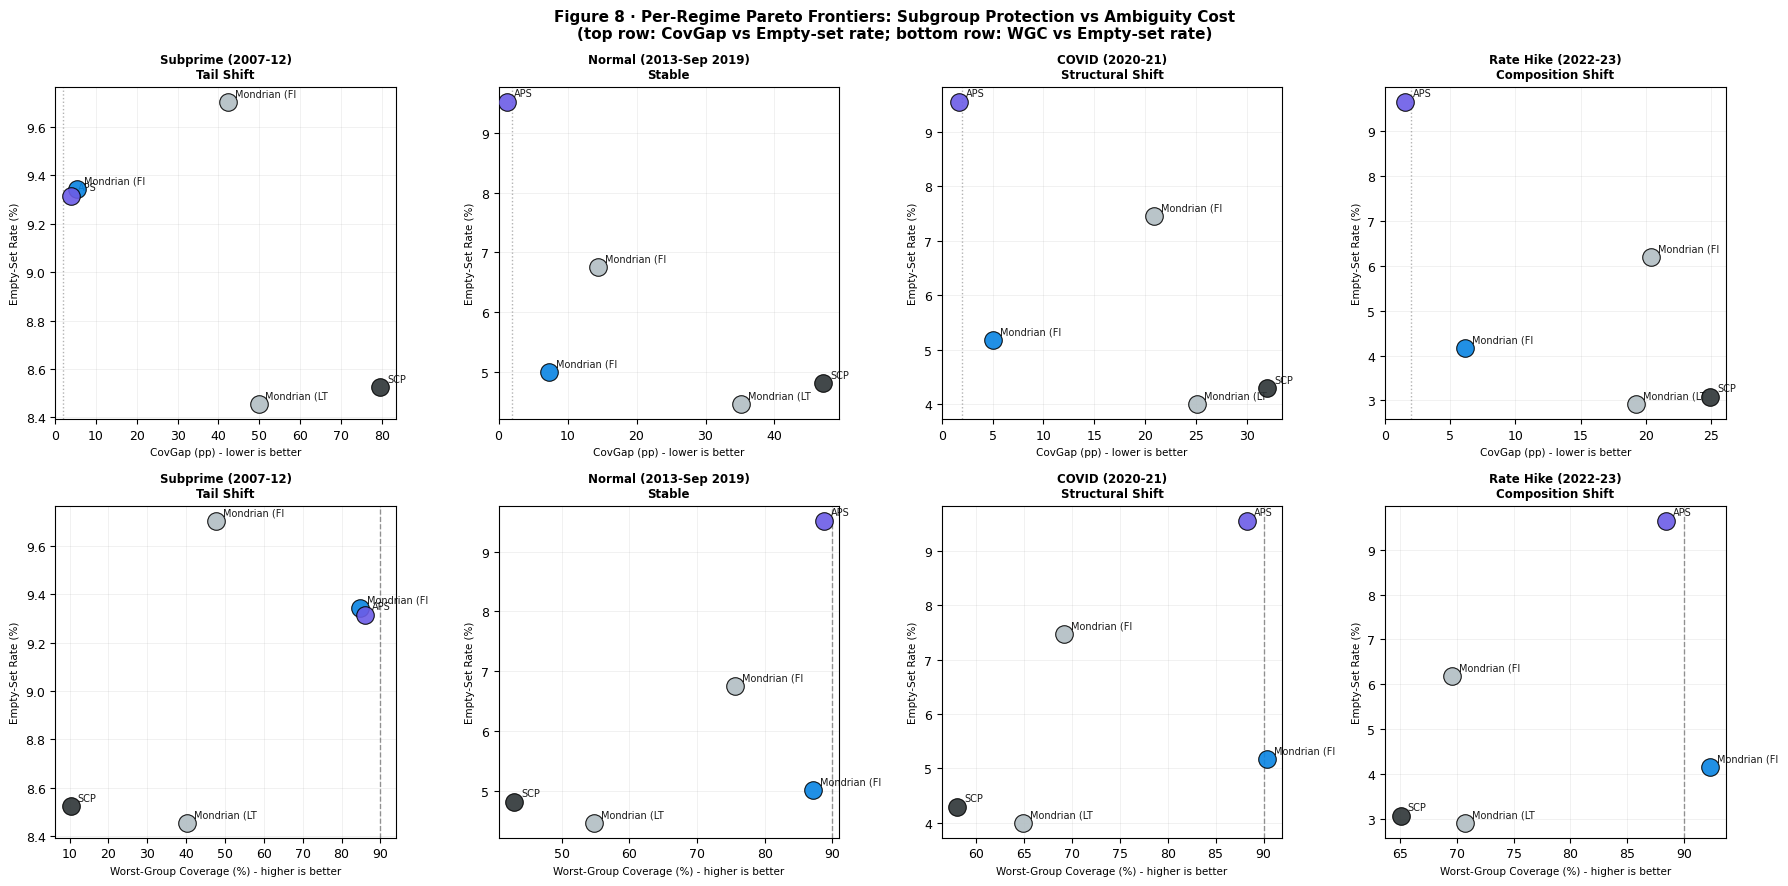

Figure 8 saved.


In [ ]:
# ── Figure 8: Exploratory static-method trade-off scatter ────────────────────
#
# Descriptive comparison of FICO×LTV reliability (CovGap/WGC) against the
# coverage-analysis empty-set rate.
# The empty-set axis is not NB09's operational review burden, and no formal
# Pareto frontier is estimated here.
#
# Adaptive methods are omitted because subgroup CovGap/WGC were not evaluated
# for them in NB06.

PARETO_METHODS = ["scp", "mondrian_fico_ltv", "aps",
                  "mondrian_fico", "mondrian_ltv"]

fig, axes = plt.subplots(2, 4, figsize=(18, 9))
fig.suptitle(
    "Figure 8 · Per-Regime Pareto Frontiers: Subgroup Protection vs Ambiguity Cost\n"
    "(top row: CovGap vs Empty-set rate; bottom row: WGC vs Empty-set rate)",
    fontsize=11, fontweight="bold"
)

for col_idx, spl in enumerate(TEST_SPLITS):
    for row_idx, (x_key, x_label, x_invert) in enumerate([
        ("covgap_pp", "CovGap (pp) - lower is better", True),
        ("wgc_pp",    "Worst-Group Coverage (%) - higher is better", False),
    ]):
        ax = axes[row_idx, col_idx]
        ax.set_title(f"{split_label(spl)}\n{HEAT_MECH[spl]}",
                     fontsize=8.5, fontweight="bold")

        for meth in PARETO_METHODS:
            row = metrics_df[(metrics_df["split"] == spl) & (metrics_df["method"] == meth)]
            if row.empty:
                continue
            r = row.iloc[0]
            er = r.get("empty_rate_pct", np.nan)
            cg = r.get("covgap_pp", np.nan)
            wgc = r.get("wgc", np.nan)

            if x_key == "covgap_pp":
                xv = cg
            else:
                xv = wgc * 100 if not np.isnan(wgc) else np.nan

            if np.isnan(xv) or np.isnan(er):
                continue

            col = METHOD_COLORS.get(meth, "#b2bec3")
            ax.scatter(xv, er, s=160, color=col, zorder=5,
                       edgecolors="black", lw=0.8, alpha=0.9)
            ax.annotate(METHOD_LABELS.get(meth, meth)[:12],
                        (xv, er), xytext=(5, 4),
                        textcoords="offset points", fontsize=7, alpha=0.9)

        ax.set_xlabel(x_label, fontsize=7.5)
        ax.set_ylabel("Empty-Set Rate (%)", fontsize=7.5)
        ax.grid(alpha=0.25)

        if x_key == "covgap_pp":
            ax.axvline(PRAC_SIG_PP, color="grey", ls=":", lw=1, alpha=0.6)
            ax.set_xlim(left=0)
        else:
            ax.axvline(90, color="black", ls="--", lw=1, alpha=0.4)

fig.tight_layout()
fig.savefig(FIG_DIR / "fig8_pareto_frontiers.png", bbox_inches="tight", dpi=FIG_DPI)
plt.show()

tradeoff_rows = []
for spl in TEST_SPLITS:
    for meth in PARETO_METHODS:
        row = metrics_df[(metrics_df["split"] == spl) & (metrics_df["method"] == meth)]
        if row.empty:
            continue
        r = row.iloc[0]
        tradeoff_rows.append({
            "split": spl,
            "method": meth,
            "mechanism": HEAT_MECH[spl],
            "marginal_cov": r.get("marginal_cov", np.nan),
            "dev_from_nom_pp": r.get("dev_from_nom_pp", np.nan),
            "empty_rate_pct": r.get("empty_rate_pct", np.nan),
            "covgap_pp": r.get("covgap_pp", np.nan),
            "wgc_pct": r.get("wgc", np.nan) * 100 if not np.isnan(r.get("wgc", np.nan)) else np.nan,
        })

tradeoff_df = pd.DataFrame(tradeoff_rows)
tradeoff_df.to_csv(NB07_OUT_DIR / "nb07_tradeoff_data.csv", index=False)
print("Figure 8 saved.")

In [ ]:
# Figure 8 underlying result data
display_full_df(
    tradeoff_df,
    title="Figure 8 underlying result data",
    sort_by=["split", "method"],
    round_digits=6,
)


=== Figure 8 underlying result data ===


,split,method,mechanism,marginal_cov,dev_from_nom_pp,empty_rate_pct,covgap_pp,wgc_pct
0,test_covid,aps,Structural Shift,0.891423,-0.857732,9.555037,1.7206,88.2794
1,test_covid,mondrian_fico,Structural Shift,0.916756,1.675625,7.462018,20.8628,69.1372
2,test_covid,mondrian_fico_ltv,Structural Shift,0.939038,3.903835,5.179061,5.0430,90.3491
3,test_covid,mondrian_ltv,Structural Shift,0.950902,5.090157,4.002248,25.0800,64.9200
4,test_covid,scp,Structural Shift,0.948271,4.827112,4.290549,31.9674,58.0326
5,test_normal,aps,Stable,0.894612,-0.538790,9.516719,1.2781,88.7219
6,test_normal,mondrian_fico,Stable,0.925643,2.564272,6.749171,14.4411,75.5589
7,test_normal,mondrian_fico_ltv,Stable,0.942687,4.268654,5.006757,7.3370,87.1075
8,test_normal,mondrian_ltv,Stable,0.948696,4.869604,4.469262,35.1834,54.8166
9,test_normal,scp,Stable,0.945482,4.548225,4.816100,47.0723,42.9277


         split            method         mechanism  marginal_cov  dev_from_nom_pp  empty_rate_pct  covgap_pp  wgc_pct
    test_covid               aps  Structural Shift      0.891423        -0.857732        9.555037     1.7206  88.2794
    test_covid     mondrian_fico  Structural Shift      0.916756         1.675625        7.462018    20.8628  69.1372
    test_covid mondrian_fico_ltv  Structural Shift      0.939038         3.903835        5.179061     5.0430  90.3491
    test_covid      mondrian_ltv  Structural Shift      0.950902         5.090157        4.002248    25.0800  64.9200
    test_covid               scp  Structural Shift      0.948271         4.827112        4.290549    31.9674  58.0326
   test_normal               aps            Stable      0.894612        -0.538790        9.516719     1.2781  88.7219
   test_normal     mondrian_fico            Stable      0.925643         2.564272        6.749171    14.4411  75.5589
   test_normal mondrian_fico_ltv            Stable      

### Interpretation

APS has the smallest FICO×LTV CovGap in all four test regimes, while Mondrian also narrows CovGap sharply relative to SCP. The matched-budget operational comparison is evaluated separately in NB09.

---
## Section 12 · Statistical Reporting

With test-window sizes of order $10^8$, an i.i.d. binomial analysis makes essentially every non-trivial deviation nominally significant. Because repeated loan-months, overlapping labels, and common calendar shocks violate independence, the Clopper-Pearson intervals below are descriptive scale diagnostics rather than panel-adjusted inference.

The thesis therefore uses the pre-specified **±2 pp** band to judge materiality.


In [ ]:
# ── Statistical reporting block ───────────────────────────────────────────────

def clopper_pearson(n_covered: int, n_total: int, alpha_ci: float = 0.05):
    """
    Exact Clopper-Pearson binomial confidence interval.

    CI = [Beta(alpha_ci/2; x, n-x+1),  Beta(1-alpha_ci/2; x+1, n-x)]
    where Beta(p; a, b) is the p-th quantile of Beta(a,b).

    Primary reference: Clopper & Pearson (1934) for the interval definition.
    Brown, Cai & DasGupta (2001) review and contextualise it.
    In this panel-data application the interval is descriptive only: the i.i.d. Bernoulli
    assumption is violated by repeated loan observations and common calendar shocks.
    See Cameron & Miller (2015) for the clustered-inference caveat.
    """
    lo = stats.beta.ppf(alpha_ci / 2, n_covered, n_total - n_covered + 1) if n_covered > 0 else 0.0
    hi = stats.beta.ppf(1 - alpha_ci / 2, n_covered + 1, n_total - n_covered) if n_covered < n_total else 1.0
    return max(lo, 0.0), min(hi, 1.0)

print("=" * 90)
print(f"{'Split':<20} {'Method':<22} {'MC (%)':>8} {'CI_lo':>8} {'CI_hi':>8} "
      f"{'Dev (pp)':>9} {'Prac. Sig.':>11} {'n':>12}")
print("=" * 90)

ci_rows = []
for spl in TEST_SPLITS:
    # Pull CI from pre-computed COV_METRICS ci_reports where available; else compute
    ci_block = COV_METRICS.get("ci_reports", {}).get(spl, {})
    for meth in PRIMARY_METHODS:
        row = metrics_df[(metrics_df["split"]==spl)&(metrics_df["method"]==meth)]
        if row.empty:
            continue
        r = row.iloc[0]
        mc = r.get("marginal_cov", np.nan)
        n  = r.get("n", np.nan)
        if np.isnan(mc) or np.isnan(n):
            continue
        n  = int(n)
        n_cov = round(mc * n)

        # Use pre-computed if available
        if meth in ci_block:
            ci_lo = ci_block[meth].get("ci_lo_95", np.nan)
            ci_hi = ci_block[meth].get("ci_hi_95", np.nan)
        else:
            ci_lo, ci_hi = clopper_pearson(n_cov, n)

        dev   = (mc - NOMINAL_COV) * 100
        prac  = "YES" if abs(dev) >= PRAC_SIG_PP else "no"

        print(f"{SPLIT_LABELS[spl].replace(chr(10),' '):<20} "
              f"{METHOD_LABELS.get(meth, meth):<22} "
              f"{mc*100:>8.3f} {ci_lo*100:>8.3f} {ci_hi*100:>8.3f} "
              f"{dev:>+9.3f} {prac:>11} {n:>12,}")

        ci_rows.append({"split":spl, "method":meth, "mc_pct":mc*100,
                        "ci_lo_pct":ci_lo*100, "ci_hi_pct":ci_hi*100,
                        "dev_pp":dev, "practical_sig":prac, "n":n})

print("=" * 90)

pd.DataFrame(ci_rows).to_csv(NB07_OUT_DIR / "nb07_ci_reports.csv", index=False)
print("\nCI table saved.")

Split                Method                   MC (%)    CI_lo    CI_hi  Dev (pp)  Prac. Sig.            n
Subprime (2007-12)   SCP                      90.515   90.512   90.517    +0.515          no  633,244,002
Subprime (2007-12)   Mondrian (FICO×LTV)      89.503   89.500   89.505    -0.497          no  633,244,002
Subprime (2007-12)   APS                      88.994   88.992   88.997    -1.006          no  633,244,002
Subprime (2007-12)   DtACI                    90.415   90.413   90.417    +0.415          no  633,244,002
Normal (2013-Sep 2019) SCP                      94.548   94.547   94.550    +4.548         YES  753,732,904
Normal (2013-Sep 2019) Mondrian (FICO×LTV)      94.269   94.267   94.270    +4.269         YES  753,732,904
Normal (2013-Sep 2019) APS                      89.461   89.459   89.463    -0.539          no  753,732,904
Normal (2013-Sep 2019) DtACI                    93.807   93.805   93.809    +3.807         YES  753,732,904
COVID (2020-21)      SCP              

In [ ]:
# ── Save class-conditional coverage table ────────────────────────────────────
cc_rows = []
for spl in ["calibration"] + TEST_SPLITS:
    for meth in PRIMARY_METHODS + ["mondrian_fico", "mondrian_ltv"]:
        row = metrics_df[(metrics_df["split"]==spl)&(metrics_df["method"]==meth)]
        if row.empty:
            continue
        r = row.iloc[0]
        cc_rows.append({
            "split"     : spl,
            "mechanism" : HEAT_MECH.get(spl,"-"),
            "method"    : METHOD_LABELS.get(meth, meth),
            "marginal_cov_pct"  : round(r.get("marginal_cov",np.nan)*100, 4),
            "cov_y0_pct"        : round(r.get("cov_y0",np.nan)*100, 4),
            "cov_y1_pct"        : round(r.get("cov_y1",np.nan)*100, 6),
            "dev_from_nom_pp"   : round(r.get("dev_from_nom_pp",np.nan), 4),
            "empty_rate_pct"    : round(r.get("empty_rate_pct",np.nan), 4),
        })
cc_df = pd.DataFrame(cc_rows)
cc_df.to_csv(NB07_OUT_DIR / "nb07_class_conditional.csv", index=False)
display_full_df(
    cc_df,
    title="Class-conditional reporting table",
    sort_by=["split", "method"],
    round_digits=None,
)

print(f"\nClass-conditional table saved.")


=== Class-conditional reporting table ===


,split,mechanism,method,marginal_cov_pct,cov_y0_pct,cov_y1_pct,dev_from_nom_pp,empty_rate_pct
0,calibration,Level 1 (Intrinsic),APS,90.0000,90.5867,37.604594,0.0000,NaN
1,calibration,Level 1 (Intrinsic),SCP,90.3027,91.3138,0.003860,0.3027,9.4060
2,test_covid,Structural Shift,APS,89.1423,90.3718,17.153035,-0.8577,9.5550
3,test_covid,Structural Shift,DtACI,94.3033,95.9140,0.000000,4.3033,4.8353
4,test_covid,Structural Shift,Mondrian (FICO),91.6756,93.2413,0.007597,1.6756,7.4620
5,test_covid,Structural Shift,Mondrian (FICO×LTV),93.9038,95.5045,0.183426,3.9038,5.1791
6,test_covid,Structural Shift,Mondrian (LTV),95.0902,96.7142,0.000000,5.0902,4.0022
7,test_covid,Structural Shift,SCP,94.8271,96.4467,0.000000,4.8271,4.2905
8,test_normal,Stable,APS,89.4612,90.3912,29.097389,-0.5388,9.5167
9,test_normal,Stable,DtACI,93.8071,95.2523,0.000210,3.8071,5.5814


         split           mechanism              method  marginal_cov_pct  cov_y0_pct  cov_y1_pct  dev_from_nom_pp  empty_rate_pct
   calibration Level 1 (Intrinsic)                 APS           90.0000     90.5867   37.604594           0.0000             NaN
   calibration Level 1 (Intrinsic)                 SCP           90.3027     91.3138    0.003860           0.3027          9.4060
    test_covid    Structural Shift                 APS           89.1423     90.3718   17.153035          -0.8577          9.5550
    test_covid    Structural Shift               DtACI           94.3033     95.9140    0.000000           4.3033          4.8353
    test_covid    Structural Shift     Mondrian (FICO)           91.6756     93.2413    0.007597           1.6756          7.4620
    test_covid    Structural Shift Mondrian (FICO×LTV)           93.9038     95.5045    0.183426           3.9038          5.1791
    test_covid    Structural Shift      Mondrian (LTV)           95.0902     96.7142    0.

---
## Section 13 · Output Manifest

Legacy-path note. This notebook writes its manifest to results/nb07/nb07_manifest.json. The executed downstream notebooks NB08–NB10 reference the legacy path manifests/analysis_manifest.json, which was present in the execution environment and provided the same NB07→NB06 bridge fields used downstream.

In [ ]:
# ── Output verification (diagnostic only) ─────────────────────────────────────
_missing_outputs = []

_required_figures = [
    "fig1_regime_reliability_heatmap.png",
    "fig2_class_conditional_coverage.png",
    "fig3a_fico_ltv_heatmap_scp_mondrian.png",
    "fig3b_aps_heatmap_wgc.png",
    "fig4_secondary_subgroup_views.png",
    "fig5_prediction_set_types.png",
    "fig6a_rolling_coverage.png",
    "fig6b_alpha_t_trajectory.png",
    "fig7a_psi_dissociation.png",
    "fig7b_transition_diagnostics.png",
    "fig8_pareto_frontiers.png",
]
for _fig in _required_figures:
    if not (FIG_DIR / _fig).exists():
        _missing_outputs.append(f"Missing figure: {_fig}")

_required_csvs = [
    "nb07_regime_summary.csv",
    "nb07_class_conditional.csv",
    "nb07_mechanism_attribution.csv",
    "nb07_regime_classification_evidence.csv",
    "nb07_tradeoff_data.csv",
    "nb07_ci_reports.csv",
]
for _csv in _required_csvs:
    _p = NB07_OUT_DIR / _csv
    if not _p.exists() or _p.stat().st_size == 0:
        _missing_outputs.append(f"Missing or empty CSV: {_csv}")

# Spot-check one key locked finding: SCP Cov(y=1) on calibration should be near-zero
_scp_cy1_cal = CP_MANIFEST["calibration_summary"]["scp_coverage_y1_cp_cal"]
if _scp_cy1_cal > 0.001:
    _missing_outputs.append(
        f"SCP Cov(y=1) on calibration = {_scp_cy1_cal:.6f}: "
        f"expected < 0.001 (Level 1 intrinsic failure check)."
    )

if _missing_outputs:
    for _err in _missing_outputs:
        print(f"  ⚠  {_err}")
else:
    print(f"✓  All NB07 outputs present ({len(_required_figures)} figures, "
          f"{len(_required_csvs)} CSVs, key numeric check).")

nb07_manifest = {
    "upstream_inputs": {
        "coverage_metrics_json"     : str(COVERAGE_METRICS_PATH),
        "mechanism_attribution_json": str(MECHANISM_ATTR_PATH),
    },
}

manifest_path = NB07_OUT_DIR / "nb07_manifest.json"
with open(manifest_path, "w") as f:
    json.dump(nb07_manifest, f, indent=2)

print("NB07 output manifest written:")
print(f"  {manifest_path}")

✓  All NB07 outputs present (11 figures, 6 CSVs, key numeric check).
NB07 output manifest written:
  /content/drive/MyDrive/master_thesis/results/nb07/nb07_manifest.json


---
## Appendix · References

### Conformal Prediction - Foundations

- Papadopoulos, H., Proedrou, K., Vovk, V., & Gammerman, A. (2002). Inductive confidence machines for regression. In T. Elomaa, H. Mannila, & H. Toivonen (Eds.), Machine learning: Ecml 2002 (pp. 345–356, Vol. 2430). Springer. https://doi.org/10.1007/3-540-36755-1_29

- Vovk, V., Gammerman, A., & Shafer, G. (2005). Algorithmic learning in a random world (1st ed.). Springer. https://doi.org/10.1007/b106715

- Lei, J., & Wasserman, L. (2014). Distribution-free prediction bands for non-parametric regression. Journal of the Royal Statistical Society Series B: Statistical Methodology, 76(1), 71–96. https://doi.org/10.1111/rssb.12021

- Angelopoulos, A. N., & Bates, S. (2023). Conformal prediction: A gentle introduction. Foundations and Trends in Machine Learning, 16(4), 494–591. https://doi.org/10.1561/2200000101

---

### Conformal Prediction - Conditional and Group Validity

- Vovk, V. (2012). Conditional validity of inductive conformal predictors. In S. C. H. Hoi & W. Buntine (Eds.), Proceedings of the asian conference on machine learning (pp. 475–490, Vol. 25). PMLR. https://proceedings.mlr.press/v25/vovk12.html

---

### Conformal Prediction - Classification Scores and APS

- Romano, Y., Sesia, M., & Candès, E. J. (2020). Classification with valid and adaptive coverage. In H. Larochelle, M. Ranzato, R. Hadsell, M.-F. Balcan, & H.-T. Lin (Eds.), Advances in neural information processing systems (pp. 3581–3591, Vol. 33). Curran Associates, Inc. https://proceedings.neurips.cc/paper/2020/hash/244edd7e85dc81602b7615cd705545f5-Abstract.html

- Sadinle, M., Lei, J., & Wasserman, L. (2019). Least ambiguous set-valued classifiers with bounded error levels. Journal of the American Statistical Association, 114(525), 223–234. https://doi.org/10.1080/01621459.2017.1395341

- Löfström, T., Boström, H., Linusson, H., & Johansson, U. (2015). Bias reduction through conditional
conformal prediction. Intelligent Data Analysis, 19(6), 1355–1375. https://doi.org/10.3233/IDA-150786

- Ding, T., Angelopoulos, A. N., Bates, S., Jordan, M. I., & Tibshirani, R. J. (2023). Class-conditional
conformal prediction with many classes. In A. Oh, T. Naumann, A. Globerson, K. Saenko,
M. Hardt, & S. Levine (Eds.), Advances in neural information processing systems (pp. 64555–
64576, Vol. 36). Curran Associates, Inc. https://doi.org/10.52202/075280-2817

---

### Conformal Prediction - Distribution Shift and Temporal Adaptation

- Foygel Barber, R., Candès, E. J., Ramdas, A., & Tibshirani, R. J. (2023). Conformal prediction beyond
exchangeability. The Annals of Statistics, 51(2), 816–845. https://doi.org/10.1214/23-AOS2276

- Gibbs, I., & Candès, E. J. (2021). Adaptive conformal inference under distribution shift. Advances in
Neural Information Processing Systems, 34, 1660–1672. https://proceedings.neurips.cc/paper/2021/hash/0d441de75945e5acbc865406fc9a2559-Abstract.html

- Gibbs, I., & Candès, E. J. (2024). Conformal inference for online prediction with arbitrary distribution
shifts. Journal of Machine Learning Research, 25(162), 1–36. https://www.jmlr.org/papers/v25/22-1218.html

---

### Online Learning Background (DtACI)

- Gradu, P., Hazan, E., & Minasyan, E. (2023). Adaptive regret for control of time-varying dynamics. In
N. Matni, M. Morari, & G. J. Pappas (Eds.), Proceedings of the 5th annual learning for dynamics
and control conference (pp. 560–572, Vol. 211). PMLR. https://proceedings.mlr.press/v211/gradu23a.html

---

### Conditional Coverage Diagnostics (NB08 boundary justification)

- Braun, S., Holzmüller, D., Jordan, M. I., & Bach, F. (2025). Conditional coverage diagnostics for confor-
mal prediction. arXiv: 2512.11779 [stat.ML]. https://doi.org/10.48550/arXiv.2512.11779

- Zhou, Z., Zhang, X., Tao, C., & Yang, Y. (2026, April 23). Conformal prediction assessment: A framework
for conditional coverage evaluation and selection. arXiv: 2603.27189v2 [stat.ME]. https://doi.org/10.48550/arXiv.2603.27189

---

### Statistical Reporting

- Clopper, C. J., & Pearson, E. S. (1934). The use of confidence or fiducial limits illustrated in the case
of the binomial. Biometrika, 26(4), 404–413. https://doi.org/10.1093/biomet/26.4.404

- Brown, L. D., Cai, T. T., & DasGupta, A. (2001). Interval estimation for a binomial
proportion. *Statistical Science, 16*(2), 101-133.
https://doi.org/10.1214/ss/1009213286

- Cameron, A. C., & Miller, D. L. (2015). A practitioner’s guide to cluster-robust inference. Journal of
Human Resources, 50(2), 317–372. https://doi.org/10.3368/jhr.50.2.317

---

### Credit Scoring and PSI Monitoring

- Siddiqi, N. (2017). Intelligent credit scoring: Building and implementing better credit risk scorecards (2nd ed.). John Wiley & Sons. https://doi.org/10.1002/9781119282396

- Yurdakul, B., & Naranjo, J. D. (2020). Statistical properties of the population stability index. Journal
of Risk Model Validation, 14(4), 89–100. https://doi.org/10.21314/JRMV.2020.227

---

### Mortgage Default and Prepayment

- Deng, Y., Quigley, J. M., & Van Order, R. (2000). Mortgage terminations, heterogeneity and the ex-
ercise of mortgage options. Econometrica, 68(2), 275–307. https://doi.org/10.1111/1468-0262.00110

- Campbell, J. Y., & Cocco, J. F. (2015). A model of mortgage default. The Journal of Finance, 70(4), 1495–1554. https://doi.org/10.1111/jofi.12252

---

### Institutional and Policy Sources (COVID Regime)

- Conference of State Bank Supervisors. (2020, June 4). CARES act forbearance & foreclosure. https://www.csbs.org/cares-act-forbearance-foreclosure

- Federal Housing Finance Agency Office of Inspector General. (2020, July 27). Oversight by fannie
mae and freddie mac of compliance with forbearance requirements under the CARES Act and
implementing guidance by mortgage servicers (Special Report No. OIG-2020-004). https://www.fhfaoig.gov/sites/default/files/OIG-2020-004.pdf